# **Data Preprocessing and Predictive Modeling Using Simple and Multiple Linear Regression**

# **Dataset Selection and Preparation**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import MinMaxScaler, StandardScaler

This module loads necessary libraries for data preprocessing, visualization, and handling so that the dataset is clean and ready for analysis and modeling.

- pandas and numpy support **data structure manipulation and numeric computation** as the foundation for data processing.
- matplotlib.pyplot and seaborn are used to **successfully visualize data trends, distributions, and relationships** as they are indispensable in exploratory data analysis.
- missingno facilitates the **identification and visualization of missing values**, enabling effective data cleaning techniques.
- OneHotEncoder ensures that **categorical variables are correctly converted to numerical form** so that they can be used with machine learning algorithms.
- MinMaxScaler and StandardScaler **scale numerical features**, avoiding problems arising from varying scales and ensuring that models learn effectively.

This block is useful since it **lays down the requisite tools for preprocessing the data**, which is a fundamental step toward constructing correct and robust machine learning models.



In [ ]:
from google.colab import drive
drive.mount('/content/drive')

This block links Google Colab to Google Drive so stored data sets and files can be accessed for analysis.

- from google.colab import drive imports the module to work with Google Drive.
- `drive.mount('/content/drive')` mounts the user's Drive into the Colab environment at the given `directory (/content/drive)`, allowing easy access to files.

This process is important in loading datasets, storing results, and having files retain their existence across Colab sessions, thus forming an integral component of workflow management in machine learning and data analysis projects.

In [ ]:
df = pd.read_csv("2022-2023 NBA Player Stats - Regular.csv", delimiter=";", encoding='latin-1')

print(df.head())

   Rk            Player Pos  Age   Tm   G  GS    MP   FG   FGA  ...    FT%  \
0   1  Precious Achiuwa   C   23  TOR  55  12  20.7  3.6   7.3  ...  0.702   
1   2      Steven Adams   C   29  MEM  42  42  27.0  3.7   6.3  ...  0.364   
2   3       Bam Adebayo   C   25  MIA  75  75  34.6  8.0  14.9  ...  0.806   
3   4      Ochai Agbaji  SG   22  UTA  59  22  20.5  2.8   6.5  ...  0.812   
4   5      Santi Aldama  PF   22  MEM  77  20  21.8  3.2   6.8  ...  0.750   

   ORB  DRB   TRB  AST  STL  BLK  TOV   PF   PTS  
0  1.8  4.1   6.0  0.9  0.6  0.5  1.1  1.9   9.2  
1  5.1  6.5  11.5  2.3  0.9  1.1  1.9  2.3   8.6  
2  2.5  6.7   9.2  3.2  1.2  0.8  2.5  2.8  20.4  
3  0.7  1.3   2.1  1.1  0.3  0.3  0.7  1.7   7.9  
4  1.1  3.7   4.8  1.3  0.6  0.6  0.8  1.9   9.0  

[5 rows x 30 columns]


This code reads the "2022-2023 NBA Player Stats - Regular.csv" file into a pandas DataFrame with `pd.read_csv()`. The delimiter=";" instructs it that the columns are semicolon-delimited rather than commas. The encoding='latin-1' is included to ensure special characters, like accented letters, are read properly.

The `print(df.head())` call prints out the **first five records** of the dataset to provide an initial look at its structure and composition. This step verifies if and when the data has loaded and been formatted correctly prior to further in-depth analysis.

In [ ]:
print("Initial shape of the dataset:", df.shape)

Initial shape of the dataset: (679, 30)


This line displays the original structure of the dataset through df.shape, which provides a tuple giving the number of rows and columns in the DataFrame. The first element is the number of overall records `(players)`, and the second is the number of features `(statistical columns)`.

It is important to know the size of the dataset **prior to any preprocessing**, be it cleaning or feature selection.

In [ ]:
print("Intial columns of the dataset:\n", df.columns)

Intial columns of the dataset:
 Index(['Rk', 'Player', 'Pos', 'Age', 'Tm', 'G', 'GS', 'MP', 'FG', 'FGA', 'FG%',
       '3P', '3PA', '3P%', '2P', '2PA', '2P%', 'eFG%', 'FT', 'FTA', 'FT%',
       'ORB', 'DRB', 'TRB', 'AST', 'STL', 'BLK', 'TOV', 'PF', 'PTS'],
      dtype='object')


This print statement prints out the first column headers of the dataset using df.columns, a list-like object that holds all column headers. By printing the column headers, **we have a view of available attributes in the dataset** so that we can discover useful features for analysis and flag any inconsistencies such as unusual symbols, spaces, or missing labels.

In [ ]:
columns_to_drop = ["Tm"]
df = df.drop(columns=columns_to_drop)

This block deletes the "Tm" column from the data by employing the `drop()` method. "Tm" is an indication of which team a given player plays in, and I found that it is not valuable enough as a data point for the following process that will occur. Dropping columns that are not needed **reduces noise, enhances computational efficiency**, and ensures that **only useful features are taken into account** in subsequent analysis and modeling.

In [ ]:
df.head()

,Rk,Player,Pos,Age,G,GS,MP,FG,FGA,FG%,...,FT%,ORB,DRB,TRB,AST,STL,BLK,TOV,PF,PTS
0,1,Precious Achiuwa,C,23,55,12,20.7,3.6,7.3,0.485,...,0.702,1.8,4.1,6.0,0.9,0.6,0.5,1.1,1.9,9.2
1,2,Steven Adams,C,29,42,42,27.0,3.7,6.3,0.597,...,0.364,5.1,6.5,11.5,2.3,0.9,1.1,1.9,2.3,8.6
2,3,Bam Adebayo,C,25,75,75,34.6,8.0,14.9,0.540,...,0.806,2.5,6.7,9.2,3.2,1.2,0.8,2.5,2.8,20.4
3,4,Ochai Agbaji,SG,22,59,22,20.5,2.8,6.5,0.427,...,0.812,0.7,1.3,2.1,1.1,0.3,0.3,0.7,1.7,7.9
4,5,Santi Aldama,PF,22,77,20,21.8,3.2,6.8,0.470,...,0.750,1.1,3.7,4.8,1.3,0.6,0.6,0.8,1.9,9.0


The following code then displays the first five records of the dataset after dropping the "Tm" column.There are only **29 columns** remaining at this point.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 679 entries, 0 to 678
Data columns (total 29 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Rk      679 non-null    int64  
 1   Player  679 non-null    object 
 2   Pos     679 non-null    object 
 3   Age     679 non-null    int64  
 4   G       679 non-null    int64  
 5   GS      679 non-null    int64  
 6   MP      679 non-null    float64
 7   FG      679 non-null    float64
 8   FGA     679 non-null    float64
 9   FG%     679 non-null    float64
 10  3P      679 non-null    float64
 11  3PA     679 non-null    float64
 12  3P%     679 non-null    float64
 13  2P      679 non-null    float64
 14  2PA     679 non-null    float64
 15  2P%     679 non-null    float64
 16  eFG%    679 non-null    float64
 17  FT      679 non-null    float64
 18  FTA     679 non-null    float64
 19  FT%     679 non-null    float64
 20  ORB     679 non-null    float64
 21  DRB     679 non-null    float64
 22  TR

The `df.info()` display presents an overview of the dataset where the number of rows is 679, and the number of columns is 29. In addition, each column's data type is included. It is also indicated here that all of the columns consist of 679 non-null values, meaning this dataset contains no missing values.

Columns that contains numeric data types:

- `int64` for categorical or count-based variables such as `Age`, `G` and `GS`.
- `float64` for continuous statistics like `FG%` and `PTS`.

Columns that contains categorical data types:
- `Player`
- `Pos`

This overview aids in measuring the completeness of the dataset and is helpful in preprocessing operations, including encoding categorical variables and scaling numerical ones for machine learning algorithms.

In [ ]:
df.dtypes

,0
Rk,int64
Player,object
Pos,object
Age,int64
G,int64
GS,int64
MP,float64
FG,float64
FGA,float64
FG%,float64


The df.dtypes function shows the data types in every column in the data set. It ensures that the **columns are numerical, with int64 applied to whole numbers** such as Rk, Age, G, and GS, while **float64 is applied to percentage-based and continuous numerical variables** like FG%, MP, and PTS. Player and Pos are **object type columns, meaning categorical data**.

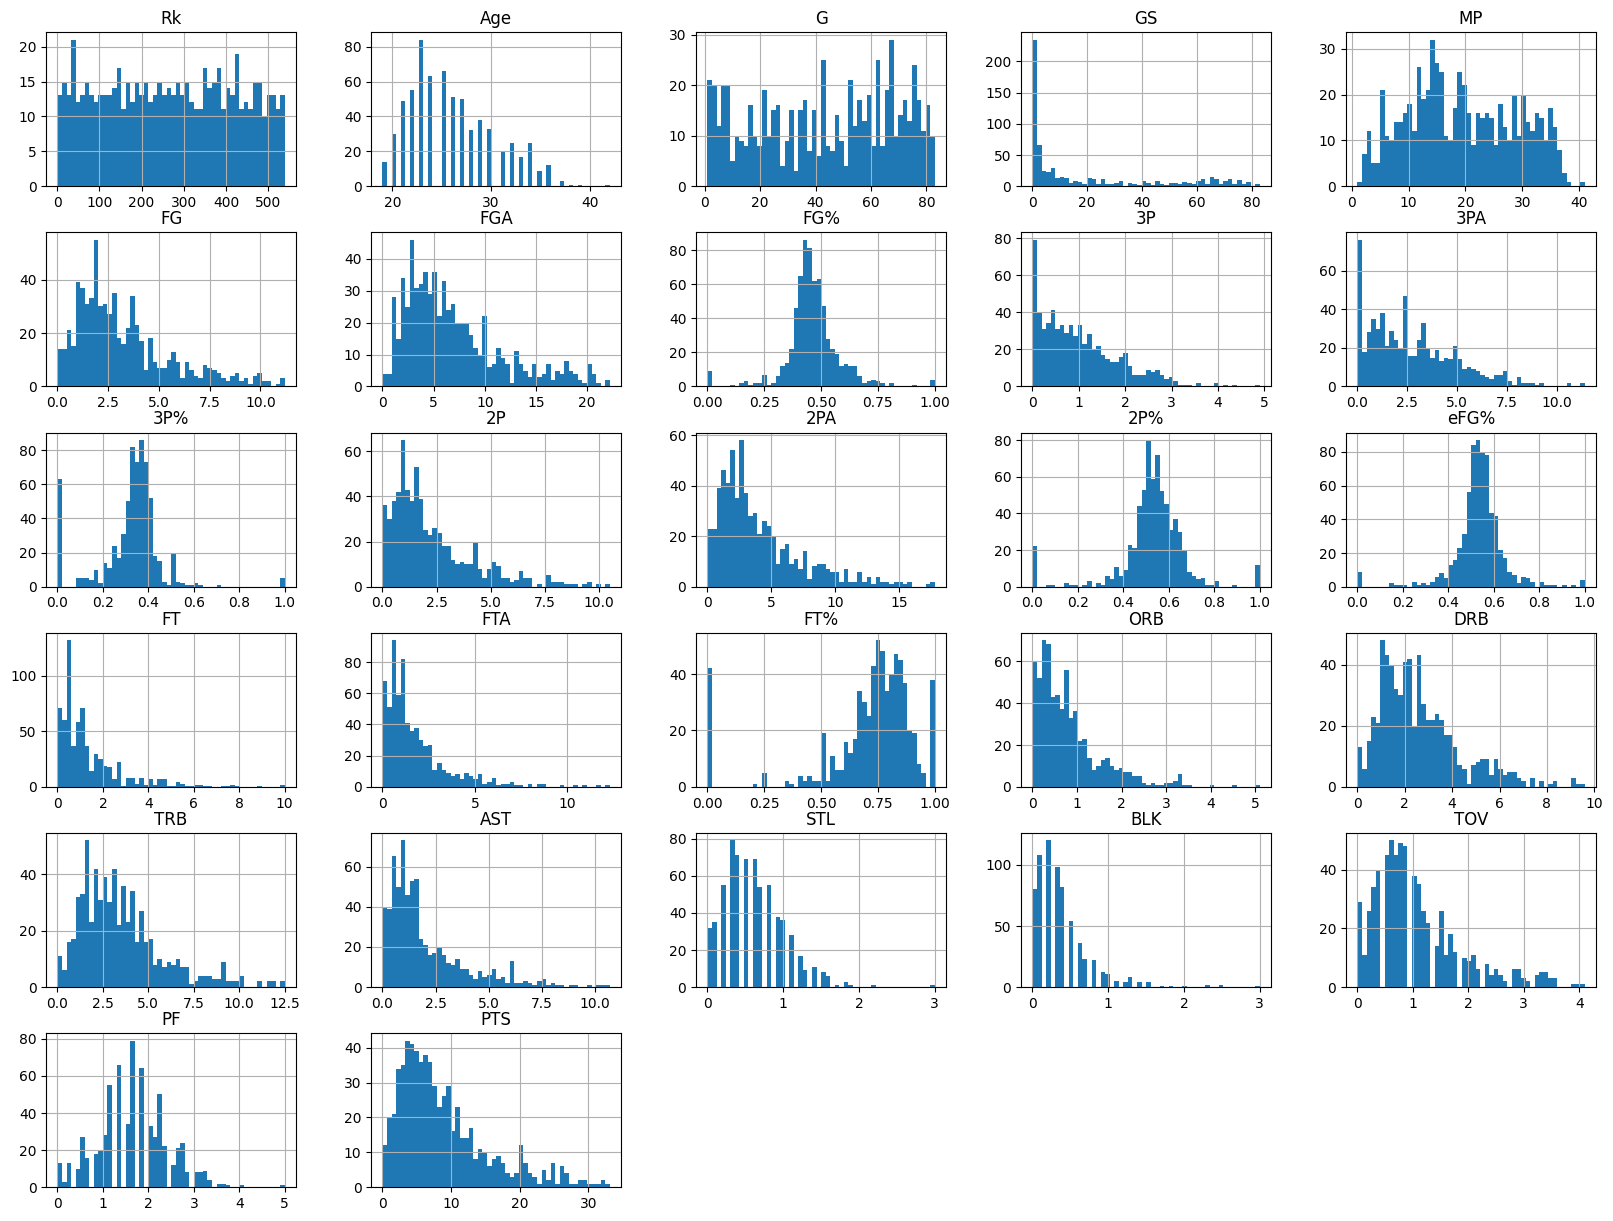

In [ ]:
df.hist(bins=50, figsize=(20,15))
plt.show()

The block of code produces histograms for each of the numerical variables in the data set with 50 bins per variable. The `figsize=(20,15)` argument sets the plots large and legible. Histograms can be employed to view the **distribution of each variable and identify if there are trends such as skewness, outliers, or whether the data is normally distributed**. This can be **helpful in feature selection, normalization, or transformation** prior to applying machine learning algorithms. The `plt.show()` function plots the histograms.

The histograms show the distribution of different NBA player statistics. Some of the observations are skewed distributions in statistics such as **Games Started (GS), Turnovers (TOV), and Blocks (BLK)**, which have a **large number of players with low values and fewer players with high values**. Shooting percentages **(FG%, 3P%, FT%) are normally distributed**, reflecting consistency among players.

In [ ]:
for column in df:
    print(f"Unique values in {column}:", df[column].nunique())
    print(f"Missing values in {column}:", df[column].isnull().sum())
    print()

Unique values in Rk: 539
Missing values in Rk: 0

Unique values in Player: 539
Missing values in Player: 0

Unique values in Pos: 8
Missing values in Pos: 0

Unique values in Age: 22
Missing values in Age: 0

Unique values in G: 83
Missing values in G: 0

Unique values in GS: 80
Missing values in GS: 0

Unique values in MP: 308
Missing values in MP: 0

Unique values in FG: 101
Missing values in FG: 0

Unique values in FGA: 174
Missing values in FGA: 0

Unique values in FG%: 279
Missing values in FG%: 0

Unique values in 3P: 40
Missing values in 3P: 0

Unique values in 3PA: 92
Missing values in 3PA: 0

Unique values in 3P%: 214
Missing values in 3P%: 0

Unique values in 2P: 83
Missing values in 2P: 0

Unique values in 2PA: 134
Missing values in 2PA: 0

Unique values in 2P%: 273
Missing values in 2P%: 0

Unique values in eFG%: 275
Missing values in eFG%: 0

Unique values in FT: 67
Missing values in FT: 0

Unique values in FTA: 80
Missing values in FTA: 0

Unique values in FT%: 263
Missin

This code loop through every column in the data set and prints the number of unique values `nunique()` and the count of missing values `isnull().sum()` per column. The **unique values assist in recognizing categorical variables** and **measuring variability** in the data, while **missing values indicate potential data quality problems** that might need to be imputed or dropped.

In [ ]:
df.to_csv('cleaned_2022-2023 NBA Player Stats - Regular.csv', index=False)

This line of code saves the current dataset up to this point, and I have used it several times in this activity in order to save all the processes, to receive the cleaned dataset file whenever needed.

# **Handling Missing Values**


In [ ]:
missing_values = df.isnull().sum()
print(missing_values.to_dict())

{'Rk': 0, 'Player': 0, 'Pos': 0, 'Age': 0, 'G': 0, 'GS': 0, 'MP': 0, 'FG': 0, 'FGA': 0, 'FG%': 0, '3P': 0, '3PA': 0, '3P%': 0, '2P': 0, '2PA': 0, '2P%': 0, 'eFG%': 0, 'FT': 0, 'FTA': 0, 'FT%': 0, 'ORB': 0, 'DRB': 0, 'TRB': 0, 'AST': 0, 'STL': 0, 'BLK': 0, 'TOV': 0, 'PF': 0, 'PTS': 0}


The code counts and prints missing values in every column of the dataset. `df.isnull().sum()` calculates the null values in every column, and `.to_dict()` transforms the result into dictionary form for easy readability. The used dataset ***contains no missing values, so, all columns hold complete data for all 679 entries***. This is a good since it eliminates imputation or data cleaning on missing values, and we can move forward with analysis without concerns of incomplete records.

In [ ]:
df.dropna(axis=1, how='all', inplace=True)

print("Remaining columns:")
print(df.columns)

Remaining columns:
Index(['Rk', 'Player', 'Pos', 'Age', 'G', 'GS', 'MP', 'FG', 'FGA', 'FG%', '3P',
       '3PA', '3P%', '2P', '2PA', '2P%', 'eFG%', 'FT', 'FTA', 'FT%', 'ORB',
       'DRB', 'TRB', 'AST', 'STL', 'BLK', 'TOV', 'PF', 'PTS'],
      dtype='object')


The line of code `df.dropna(axis=1, how='all', inplace=True)` deletes columns consisting solely of missing values `(NaN)`. Because there are no missing values in the dataset as can be seen in the above output, **no columns will be deleted**, and **df.columns will still have all the columns** as originally presented.

In [ ]:
df.dropna(inplace=True)

print("Shape of DataFrame after removing rows with missing values:", df.shape)

Shape of DataFrame after removing rows with missing values: (679, 29)


The line `df.dropna(inplace=True)` deletes rows containing missing values, changing the DataFrame in place. Since the prior run of code indicated no missing values, this action did not affect the dataset. The shape is still `(679, 29)`, so all rows and columns remains.

In [ ]:
print("Columns of the dataset after handling missing values:\n", df.columns)

print("\nShape of DataFrame after removing columns with missing values:", df.shape)

Columns of the dataset after handling missing values:
 Index(['Rk', 'Player', 'Pos', 'Age', 'G', 'GS', 'MP', 'FG', 'FGA', 'FG%', '3P',
       '3PA', '3P%', '2P', '2PA', '2P%', 'eFG%', 'FT', 'FTA', 'FT%', 'ORB',
       'DRB', 'TRB', 'AST', 'STL', 'BLK', 'TOV', 'PF', 'PTS'],
      dtype='object')

Shape of DataFrame after removing columns with missing values: (679, 29)


This code checks the DataFrame's structure after the missing values were dealt with. It initially **prints the column headers** to ensure no critical data was lost. Then it **prints the shape of the DataFrame**, which indicates the number of rows and columns. Since no missing values were found before, the **dataset is still intact at (679, 29)**, which ensures data integrity.

In [ ]:
df.to_csv('cleaned_2022-2023 NBA Player Stats - Regular.csv', index=False)

The current dataset condition is saved again, after handling missing values.

# **Dealing with Duplicates**

In [ ]:
for column in df.columns:
    print(f"Unique values in {column}:", df[column].nunique())
    print(f"Number of duplicates in '{column}' column: {df[column].duplicated().sum()} \n")

Unique values in Rk: 539
Number of duplicates in 'Rk' column: 140 

Unique values in Player: 539
Number of duplicates in 'Player' column: 140 

Unique values in Pos: 8
Number of duplicates in 'Pos' column: 671 

Unique values in Age: 22
Number of duplicates in 'Age' column: 657 

Unique values in G: 83
Number of duplicates in 'G' column: 596 

Unique values in GS: 80
Number of duplicates in 'GS' column: 599 

Unique values in MP: 308
Number of duplicates in 'MP' column: 371 

Unique values in FG: 101
Number of duplicates in 'FG' column: 578 

Unique values in FGA: 174
Number of duplicates in 'FGA' column: 505 

Unique values in FG%: 279
Number of duplicates in 'FG%' column: 400 

Unique values in 3P: 40
Number of duplicates in '3P' column: 639 

Unique values in 3PA: 92
Number of duplicates in '3PA' column: 587 

Unique values in 3P%: 214
Number of duplicates in '3P%' column: 465 

Unique values in 2P: 83
Number of duplicates in '2P' column: 596 

Unique values in 2PA: 134
Number of du

This loop iterates over all columns in the DataFrame to check for its uniqueness and duplication. It first prints the **number of unique values in each column**, which can be utilized to **detect categorical variables or redundancies**. It then c**hecks for duplicate values in each column**, which can be utilized to **detect inconsistencies or repetitions** in the dataset. This is to verify data quality prior to further processing.

Categorical columns such as `Pos` with very few unique values, whereas numerical columns such as `PTS` and `FG%` contain many unique values. Columns such as `Rk` and `Player` indicate duplicate records, which can represent **repeated records of players**.

In [ ]:
unique_columns = []
for column in df.columns:
    if df[column].nunique() == len(df):
        unique_columns.append(column)

print("Columns where each row is unique:")
print(unique_columns)

Columns where each row is unique:
[]


It then checks if columns have all unique values and no duplicate values. It does this by comparing the total unique number of values in each column `df[column].nunique()` and the total rows `len(df)`. The column will only be considered unique when the two are equal, hence appending it to unique_columns. Since the output is an empty list `[]`, this shows that **none of the columns in the data contains entirely unique values**. There are at least some duplicated records in every column.

In [ ]:
for column in df.columns:
    print(f"Unique values in column '{column}':")
    print(df[column].unique())
    print()

Unique values in column 'Rk':
[  1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17  18
  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35  36
  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53  54
  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71  72
  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89  90
  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107 108
 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125 126
 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142 143 144
 145 146 147 148 149 150 151 152 153 154 155 156 157 158 159 160 161 162
 163 164 165 166 167 168 169 170 171 172 173 174 175 176 177 178 179 180
 181 182 183 184 185 186 187 188 189 190 191 192 193 194 195 196 197 198
 199 200 201 202 203 204 205 206 207 208 209 210 211 212 213 214 215 216
 217 218 219 220 221 222 223 224 225 226 227 228 229 230 231 232 233 234
 235 236 237 238 239 

This script loops over every column in the DataFrame and prints out all the unique values in that column. The `df[column].unique()` command gets an array of unique values in the column, which enables a view of the variability of the dataset. This assists in detecting **categorical values, possible inconsistencies, and patterns** in the data. The extra newline (`print()`) provides easier readability by inserting a newline for each column.

In [ ]:
print("Number of duplicate player entries:", df["Player"].duplicated().sum())

Number of duplicate player entries: 140


This script counts and displays duplicate records in the "Player" field. The `df["Player"].duplicated().sum()` method identifies multiple occurrences of the same player's name and counts them up to find that there are **140 player records present more than once in the dataset**. This aids in evaluating whether there are several records for the same player, which may imply duplicate records.

# **Combining stats of players who were traded, thus playing on different teams, generating duplicate rows**

In [ ]:
df["Original_Order"] = df.index


df = df.groupby("Player", as_index=False).agg({
    "Age": "first",
    "G": "sum",
    "GS": "sum",
    "MP": "mean",
    "FG": "sum", "FGA": "sum", "FG%": "mean",
    "3P": "sum", "3PA": "sum", "3P%": "mean",
    "2P": "sum", "2PA": "sum", "2P%": "mean",
    "eFG%": "mean",
    "FT": "sum", "FTA": "sum", "FT%": "mean",
    "ORB": "sum", "DRB": "sum", "TRB": "sum",
    "AST": "sum", "STL": "sum", "BLK": "sum",
    "TOV": "sum", "PF": "sum", "PTS": "sum",
    "Original_Order": "min"
})


df = df.sort_values(by="Original_Order").drop(columns=["Original_Order"])


df.reset_index(drop=True, inplace=True)
df.head()

,Player,Age,G,GS,MP,FG,FGA,FG%,3P,3PA,...,FT%,ORB,DRB,TRB,AST,STL,BLK,TOV,PF,PTS
0,Precious Achiuwa,23,55,12,20.7,3.6,7.3,0.485,0.5,2.0,...,0.702,1.8,4.1,6.0,0.9,0.6,0.5,1.1,1.9,9.2
1,Steven Adams,29,42,42,27.0,3.7,6.3,0.597,0.0,0.0,...,0.364,5.1,6.5,11.5,2.3,0.9,1.1,1.9,2.3,8.6
2,Bam Adebayo,25,75,75,34.6,8.0,14.9,0.540,0.0,0.2,...,0.806,2.5,6.7,9.2,3.2,1.2,0.8,2.5,2.8,20.4
3,Ochai Agbaji,22,59,22,20.5,2.8,6.5,0.427,1.4,3.9,...,0.812,0.7,1.3,2.1,1.1,0.3,0.3,0.7,1.7,7.9
4,Santi Aldama,22,77,20,21.8,3.2,6.8,0.470,1.2,3.5,...,0.750,1.1,3.7,4.8,1.3,0.6,0.6,0.8,1.9,9.0


This code merges duplicate player rows by grouping the data by "Player" and summing up their statistics. It initially saves the original position in an "Original_Order" column. Next, it groups by "Player" and uses various aggregation functions:
- summing total games played, field goals made, rebounds, and other counting statistics, and averaging percentage statistics such as FG%, 3P%, and eFG%.

Once aggregated, it reorders back to its original order based on "Original_Order" and ultimately drops this auxiliary column. It resets the index to preserve an untidy DataFrame format for every player so **they only have a single record of their stats**.

In [ ]:
print("Number of duplicate player entries after merging:", df["Player"].duplicated().sum())

Number of duplicate player entries after merging: 0


This verifies that after merging duplicate player rows, every player now has only one, exclusive row in the dataset. The `.duplicated().sum()` command returns zero, indicating **no duplicate player names are left in the dataset**. This guarantees player statistics are all correctly aggregated and enhances data integrity for further analysis.

In [ ]:
print(df)

               Player  Age   G  GS    MP   FG   FGA    FG%   3P  3PA  ...  \
0    Precious Achiuwa   23  55  12  20.7  3.6   7.3  0.485  0.5  2.0  ...   
1        Steven Adams   29  42  42  27.0  3.7   6.3  0.597  0.0  0.0  ...   
2         Bam Adebayo   25  75  75  34.6  8.0  14.9  0.540  0.0  0.2  ...   
3        Ochai Agbaji   22  59  22  20.5  2.8   6.5  0.427  1.4  3.9  ...   
4        Santi Aldama   22  77  20  21.8  3.2   6.8  0.470  1.2  3.5  ...   
..                ...  ...  ..  ..   ...  ...   ...    ...  ...  ...  ...   
534    Thaddeus Young   34  54   9  14.7  2.0   3.7  0.545  0.1  0.6  ...   
535        Trae Young   24  73  73  34.8  8.2  19.0  0.429  2.1  6.3  ...   
536    Omer Yurtseven   24   9   0   9.2  1.8   3.0  0.593  0.3  0.8  ...   
537       Cody Zeller   30  15   2  14.5  2.5   3.9  0.627  0.0  0.1  ...   
538       Ivica Zubac   25  76  76  28.6  4.3   6.8  0.634  0.0  0.0  ...   

       FT%  ORB  DRB   TRB   AST  STL  BLK  TOV   PF   PTS  
0    0.702  1.

This line of code then displays the current dataset with all of its rows and columns, after handling duplicate values. We can see that there are now only **539 rows and 27 columns remaining**. 27 columns remained as `Rk` and `Pos` were not included in the aggregation.

In [ ]:
df.to_csv('cleaned_2022-2023 NBA Player Stats - Regular.csv', index=False)

Once again, I saved the current condition of the dataset after handling duplicate values.

# **Dealing with Outliers**

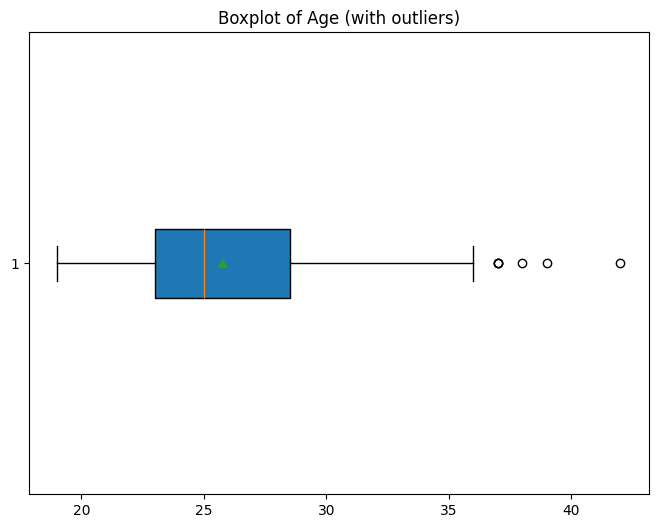

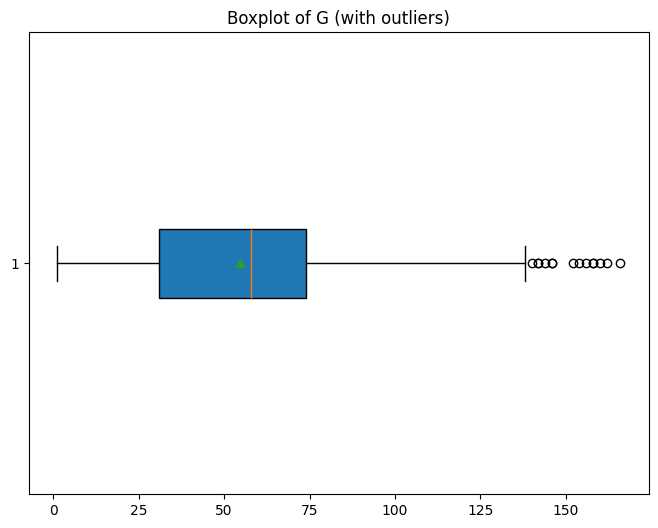

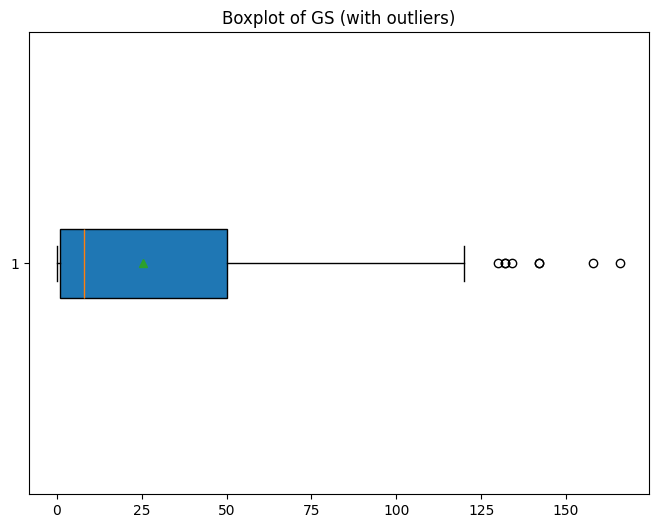

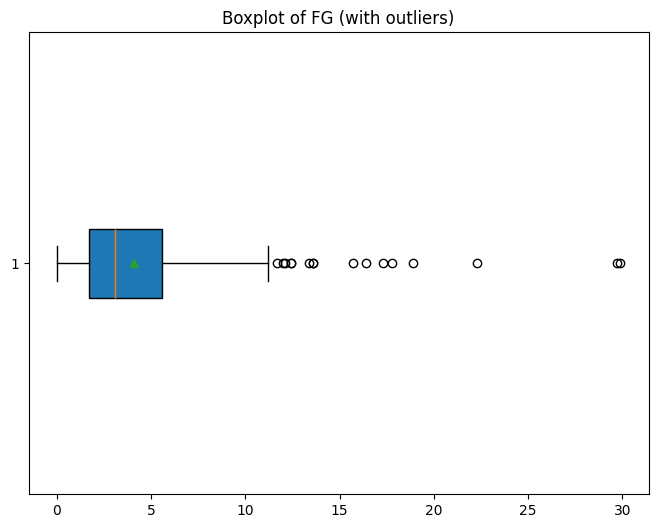

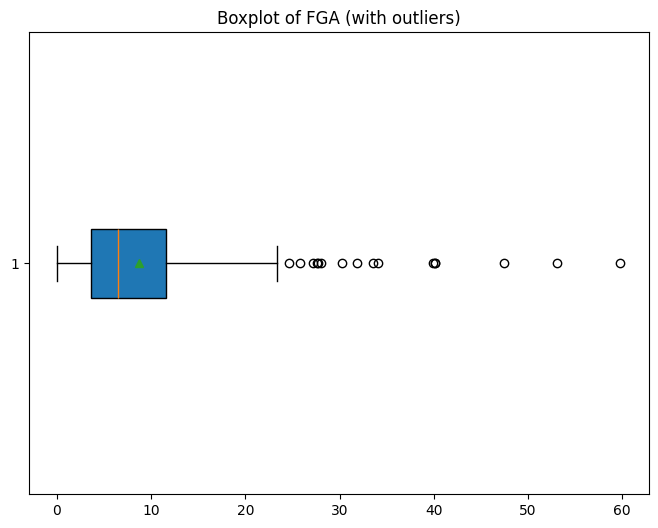

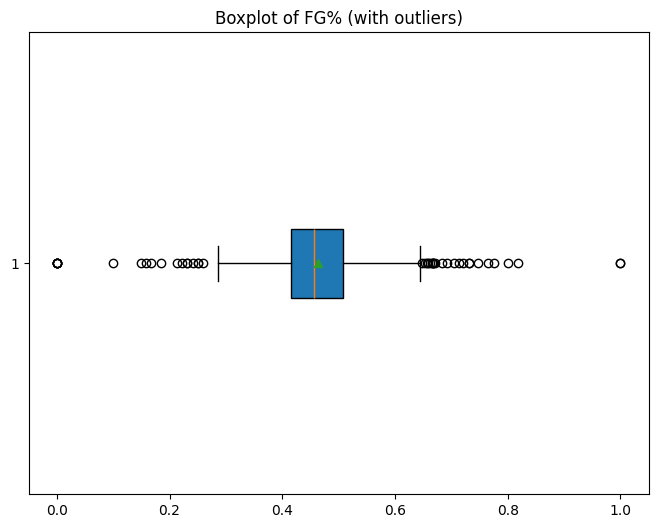

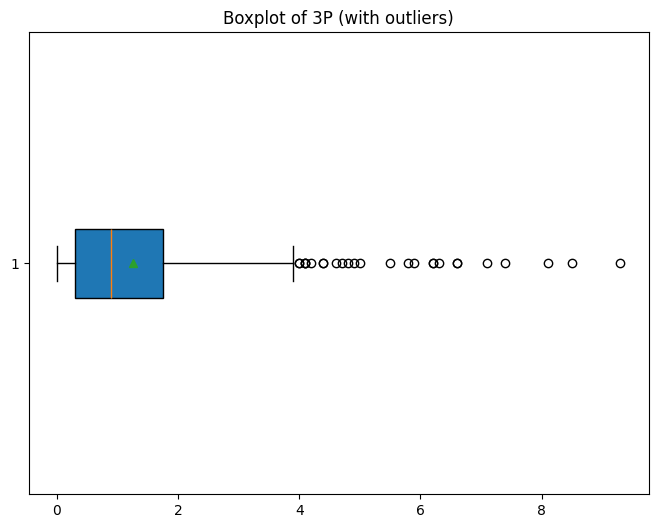

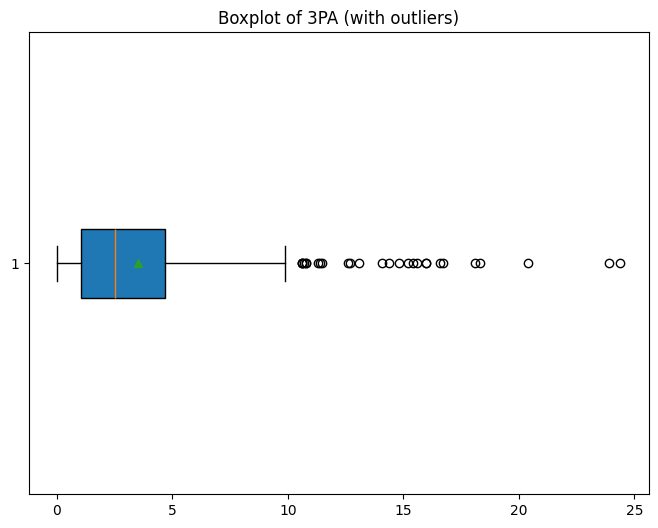

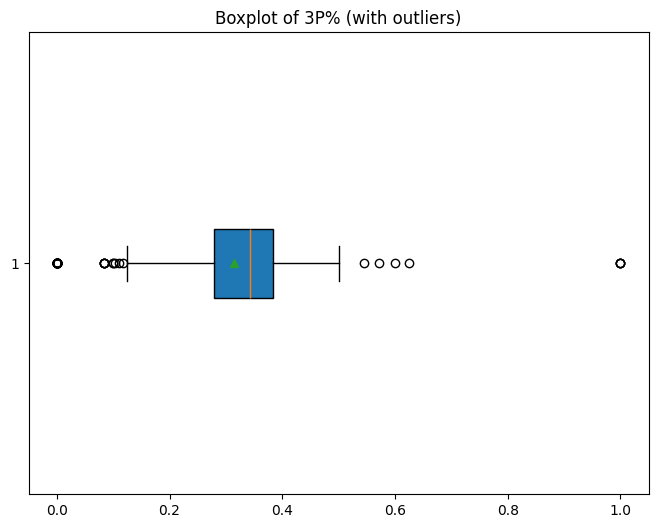

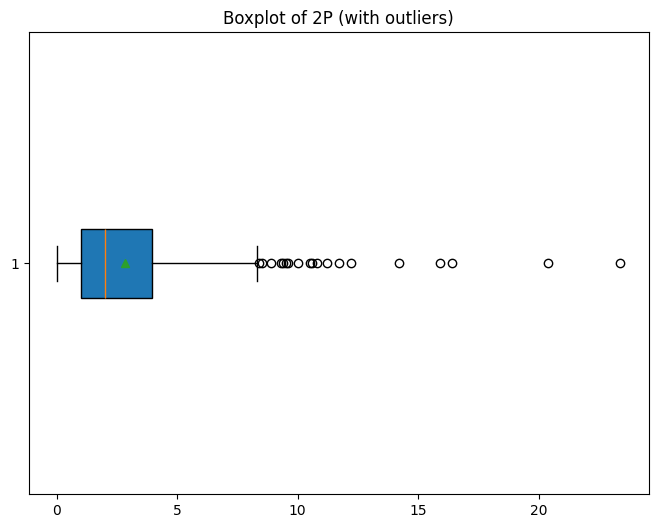

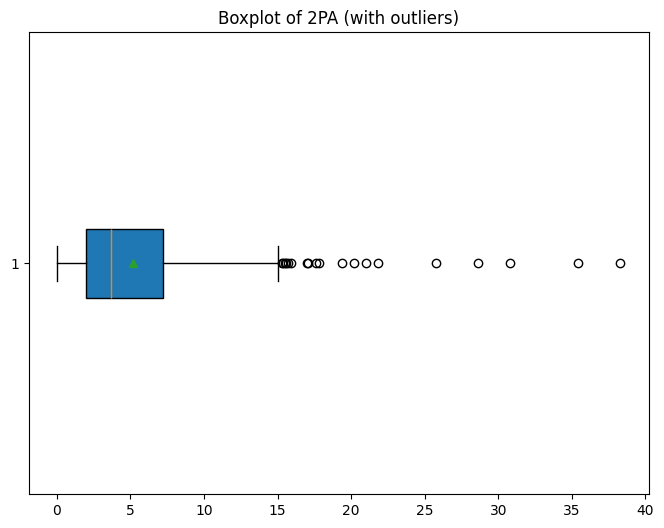

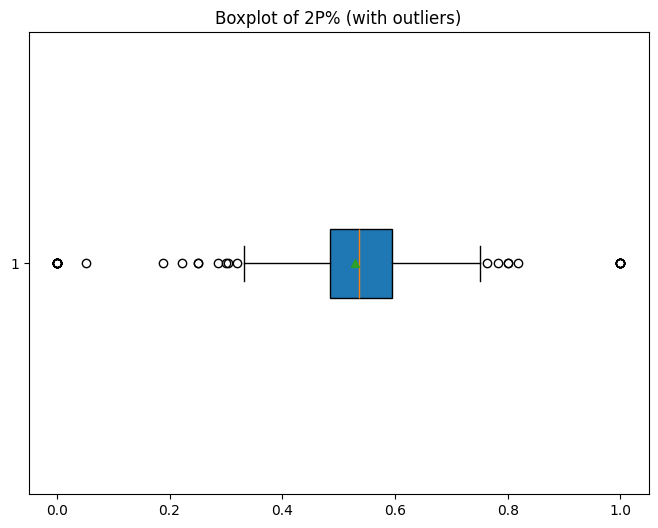

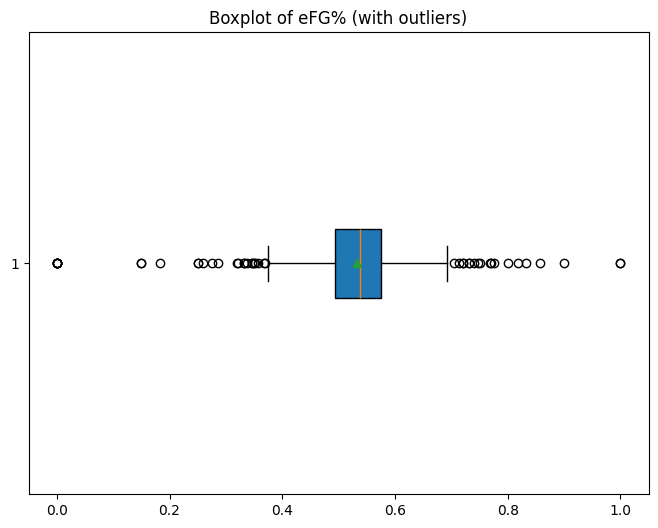

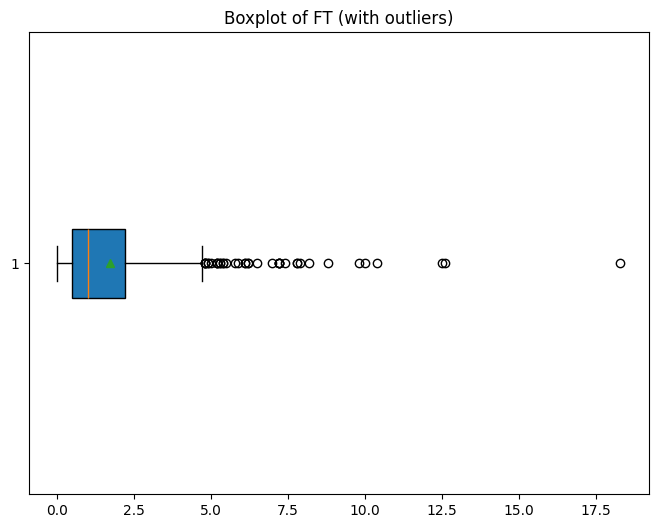

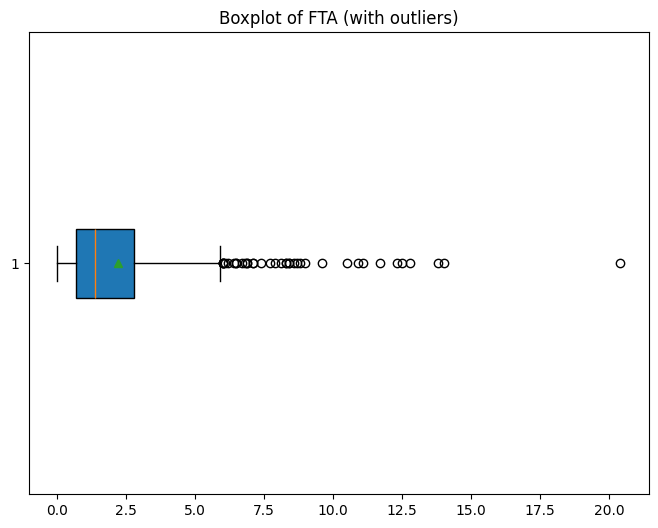

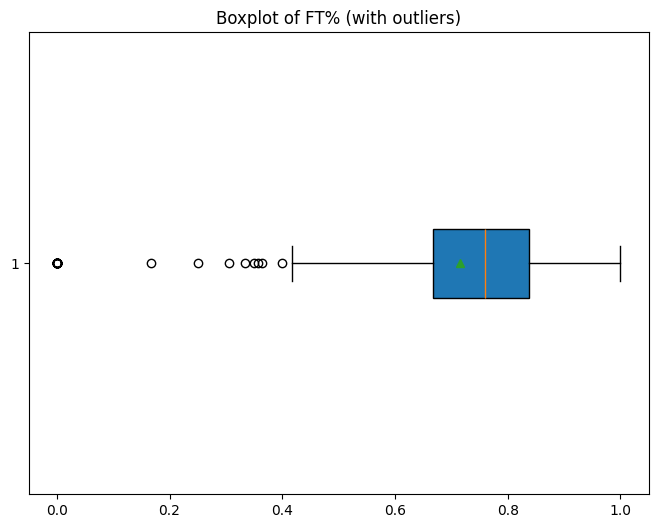

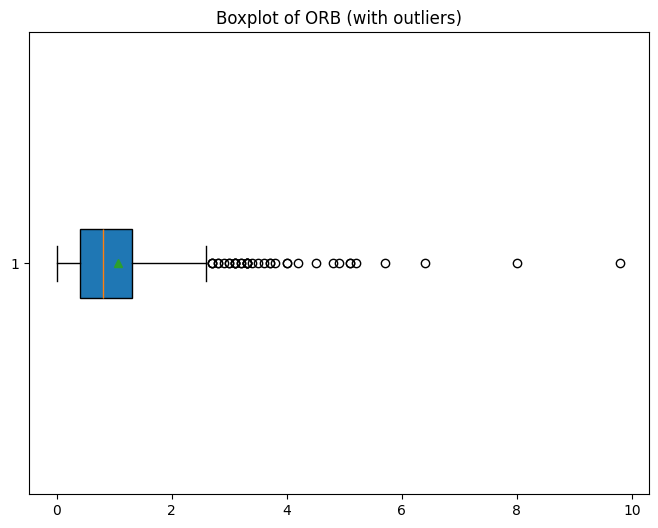

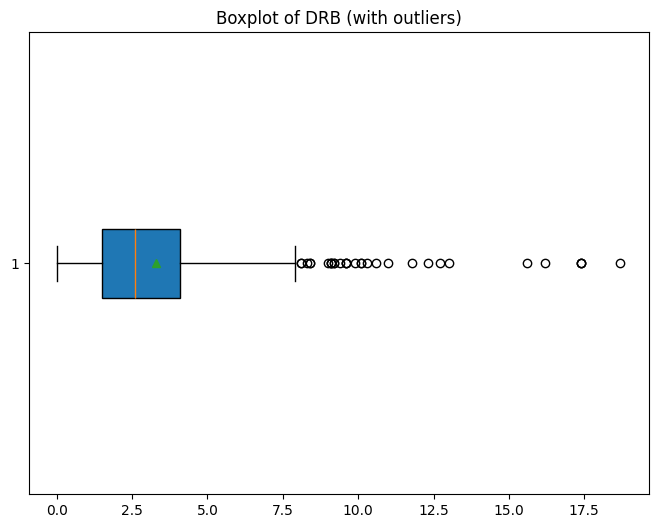

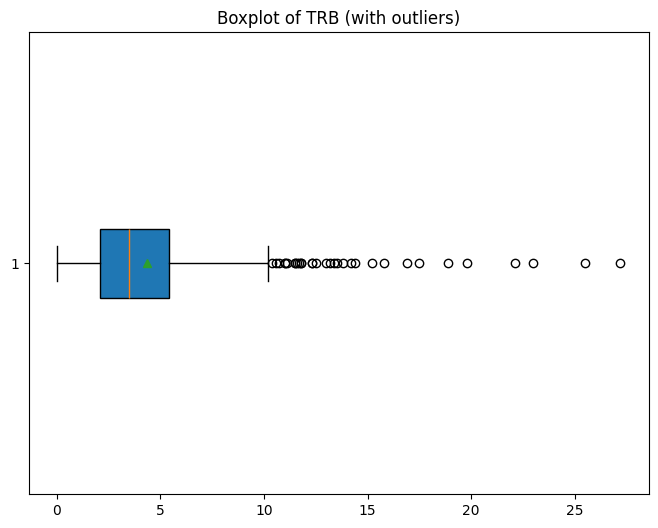

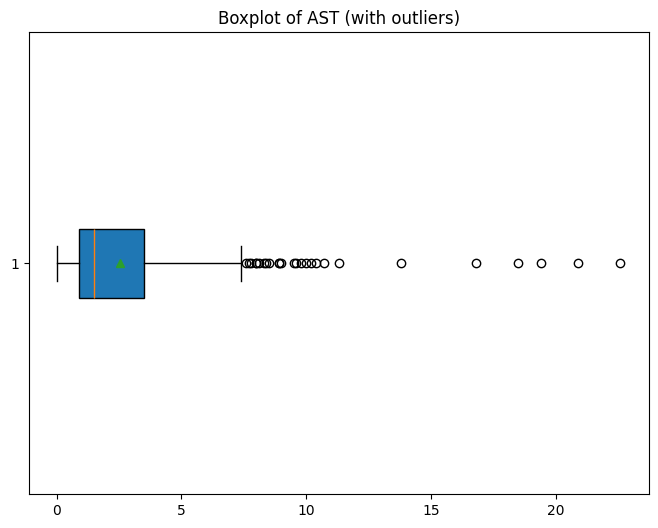

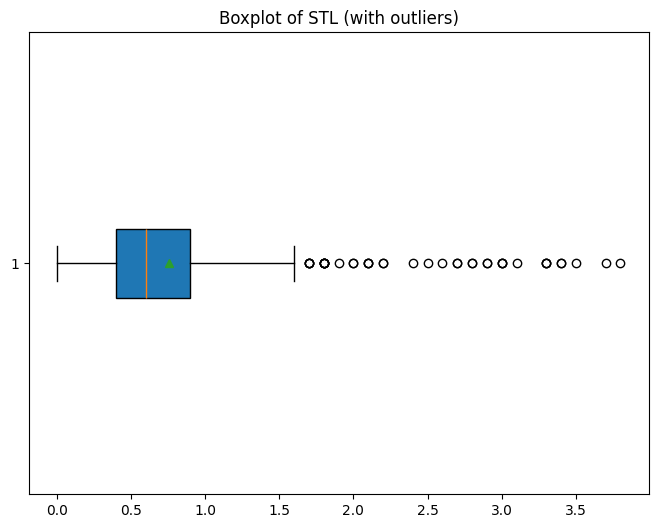

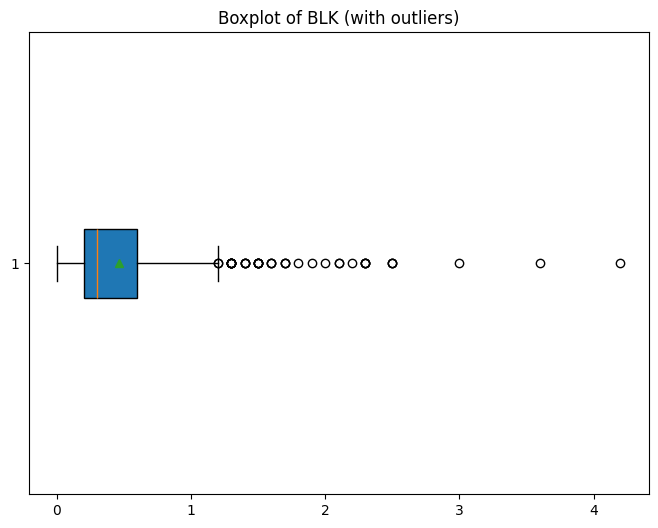

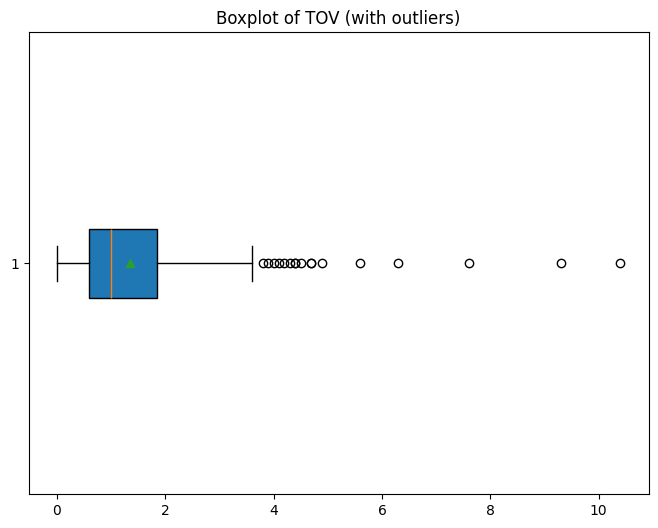

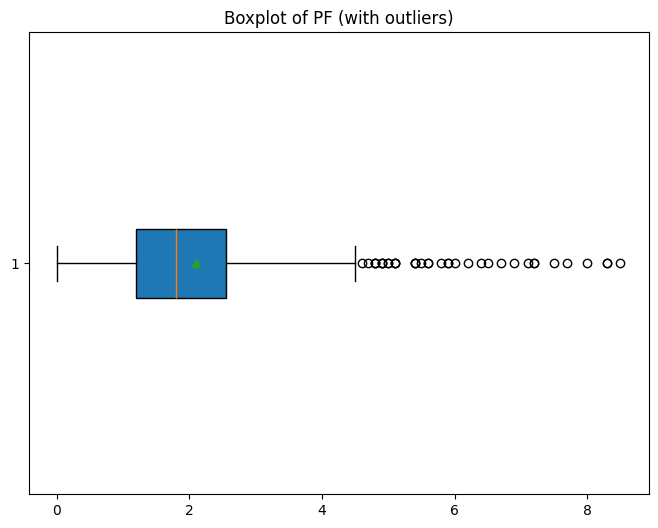

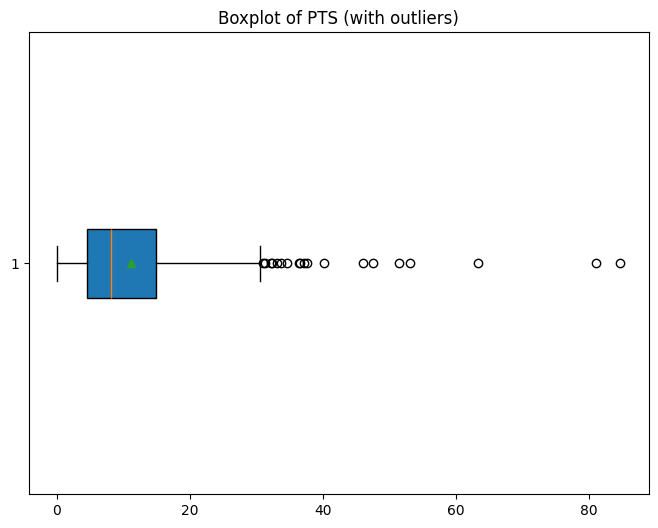

In [ ]:
def detect_outliers_iqr(df):
    outliers = {}
    for column in df.select_dtypes(include=['float64', 'int64']).columns:
        Q1 = df[column].quantile(0.25)
        Q3 = df[column].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        column_outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)][column]
        if not column_outliers.empty:
            outliers[column] = column_outliers
    return outliers

outliers_iqr = detect_outliers_iqr(df)

for column, values in outliers_iqr.items():
    plt.figure(figsize=(8, 6))
    plt.boxplot(df[column], vert=False, patch_artist=True, showmeans=True)
    plt.title(f'Boxplot of {column} (with outliers)')
    plt.show()


The code identifies outliers based on the **Interquartile Range (IQR)** method and plots them via boxplots. It then loops over all the numeric columns of the data, namely** float64 and int64**.

- For each column, it computes the **first quartile (Q1), third quartile (Q3)**, and the **interquartile range (IQR**), which is the difference between Q3 and Q1.

- With this, it calculates the lower and upper limits by subtracting and adding 1.5 times the IQR from Q1 and Q3, respectively.

- Any values outside these limits are considered outliers and are placed in a dictionary. If there are outliers in a column, a boxplot is created to **visually show the distribution of values, including the extreme values**.

This helped me identify strange data points that could require additional analysis or preprocessing, since **I also didn't know my dataset had a lot of outliers prior to executing this block of code**.

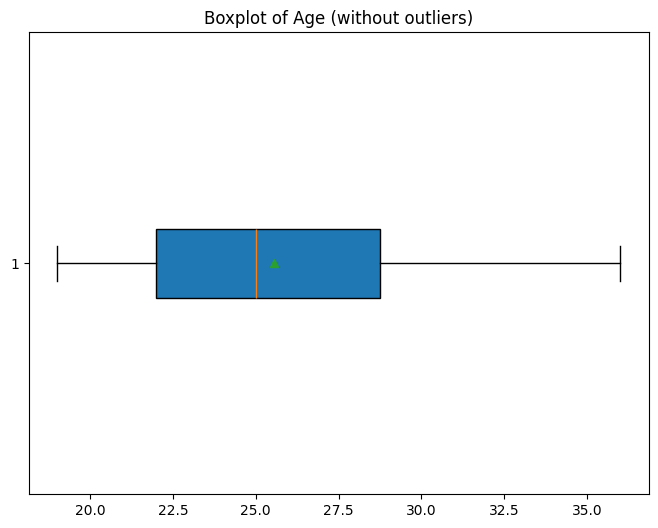

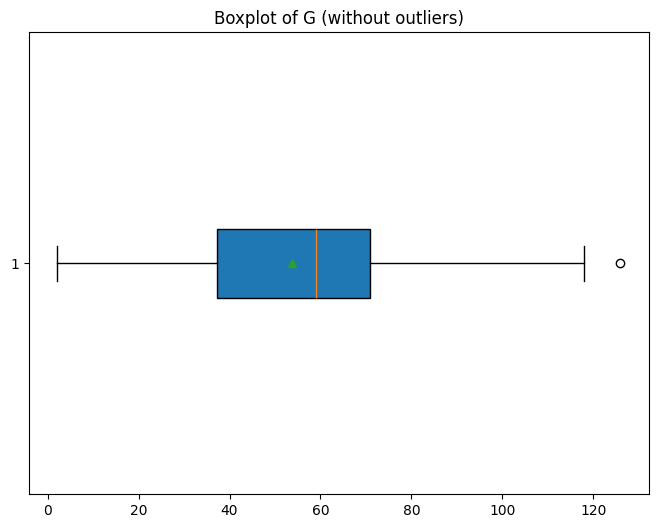

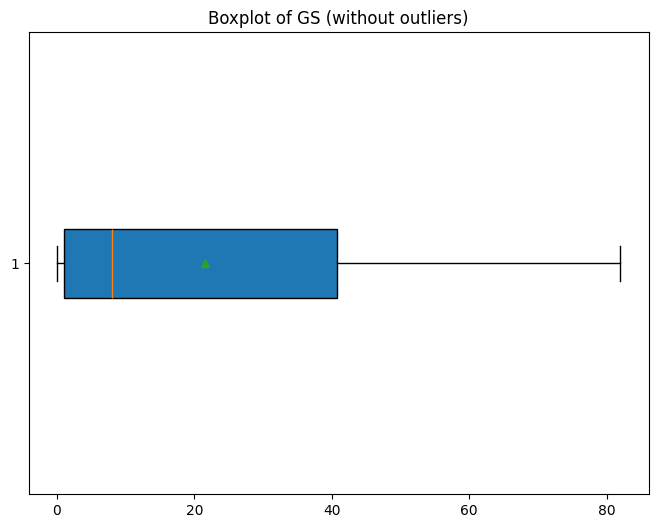

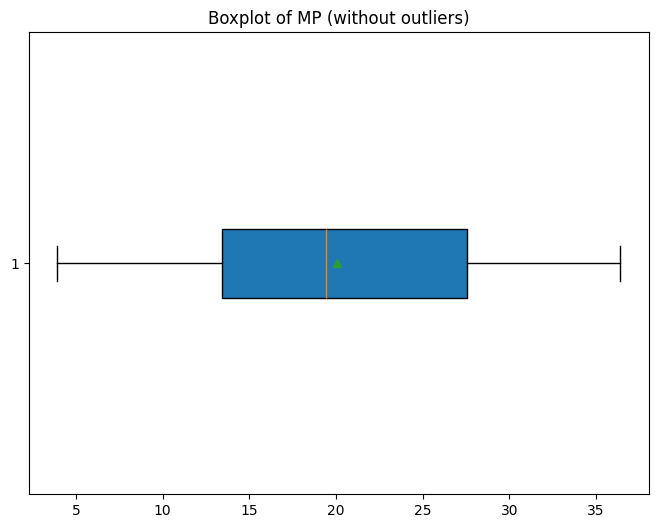

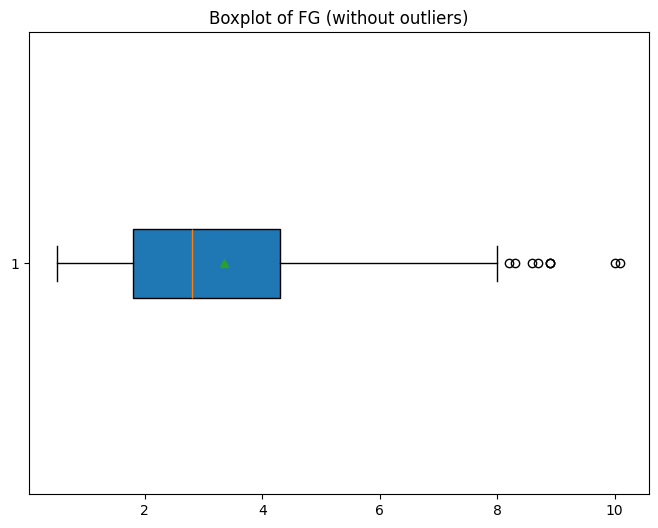

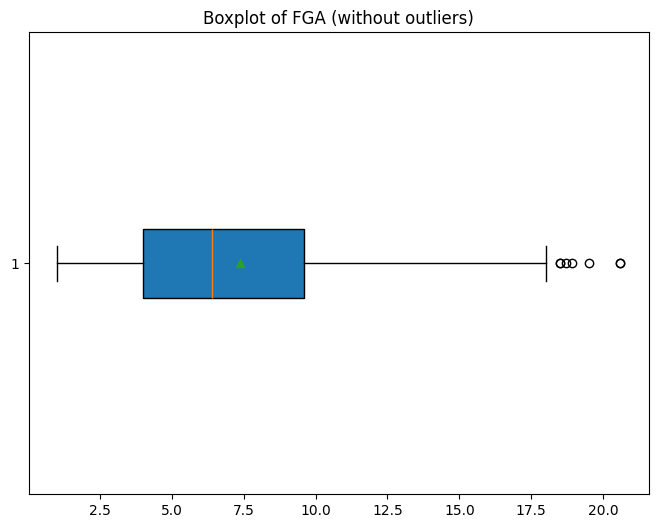

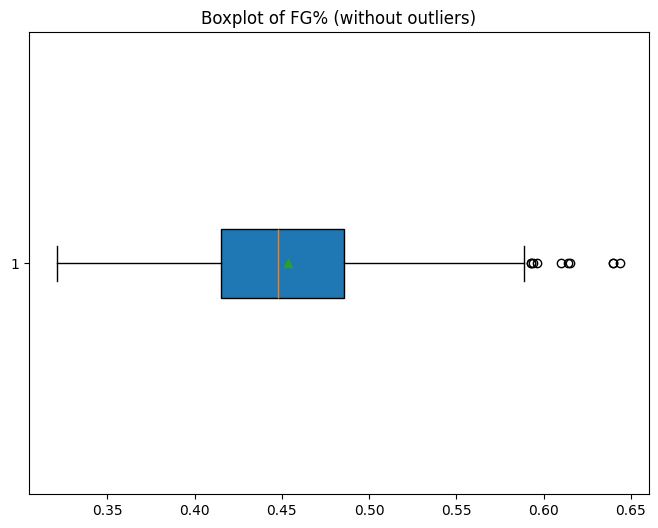

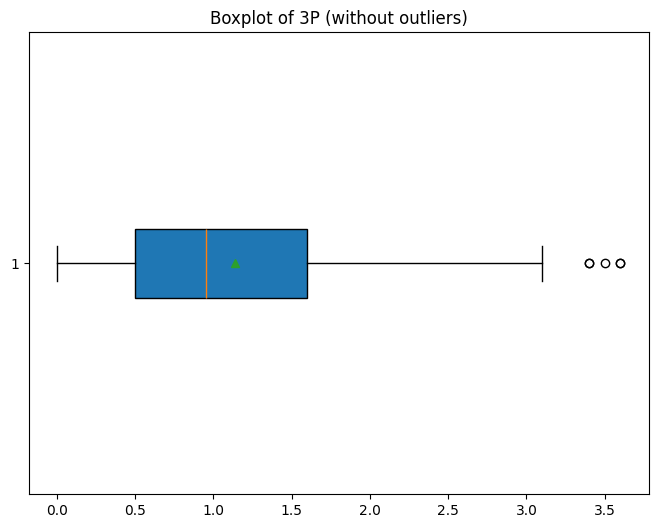

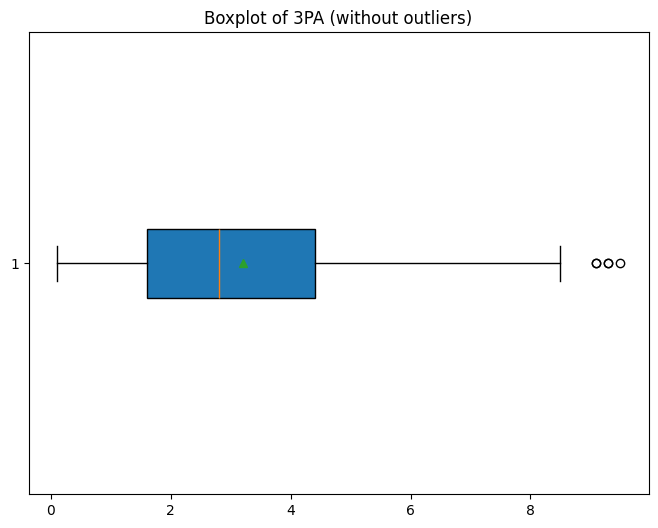

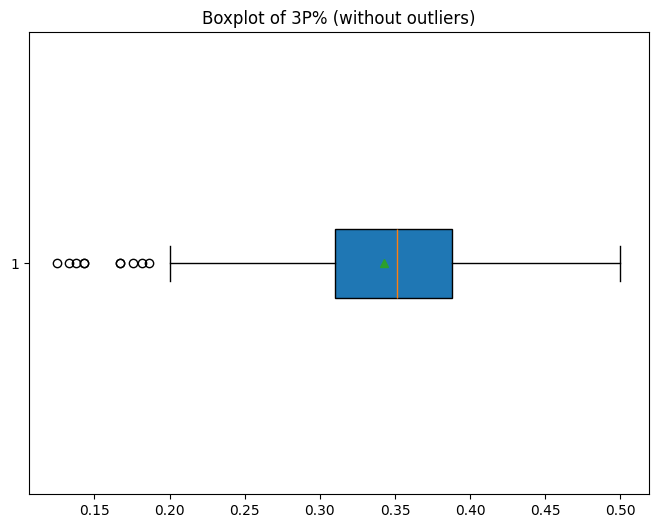

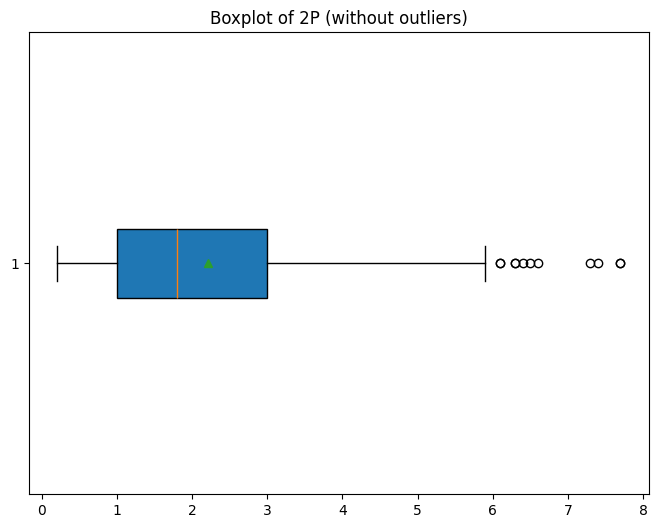

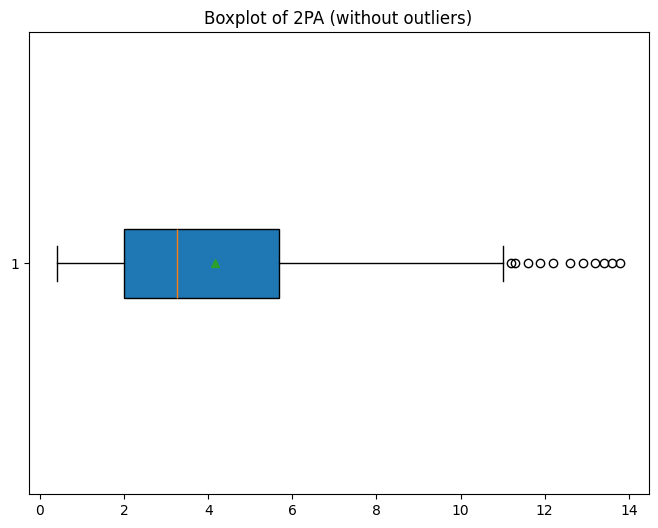

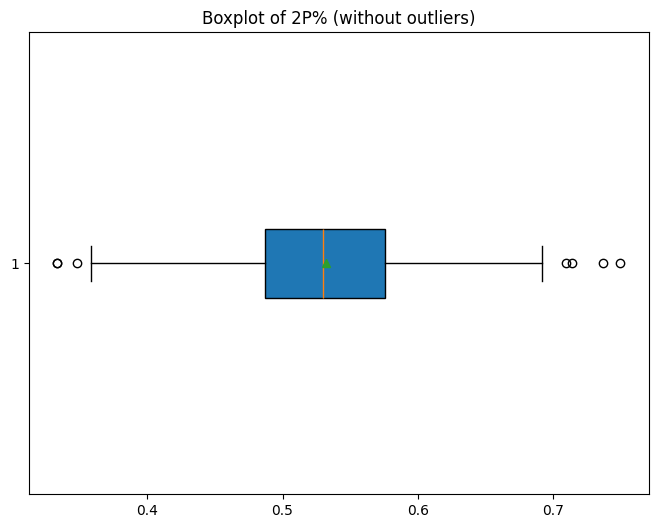

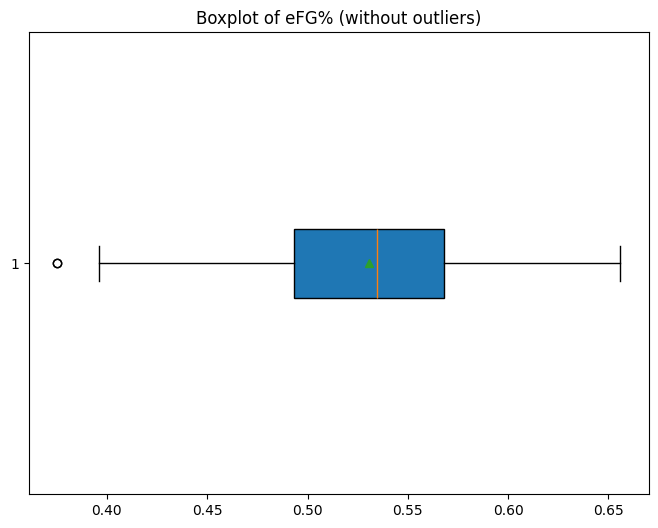

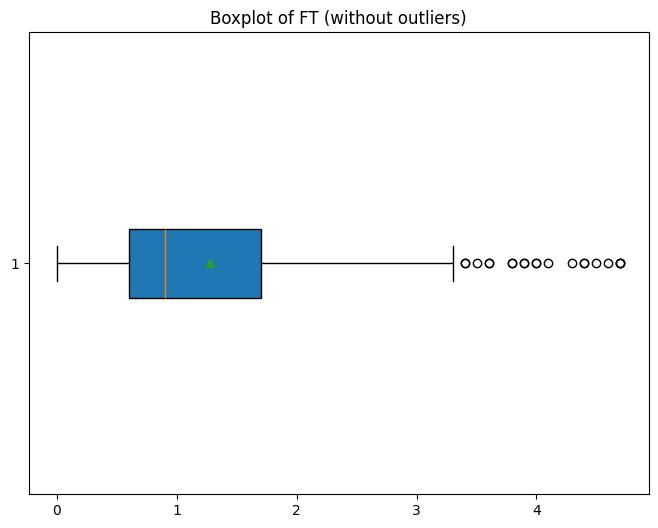

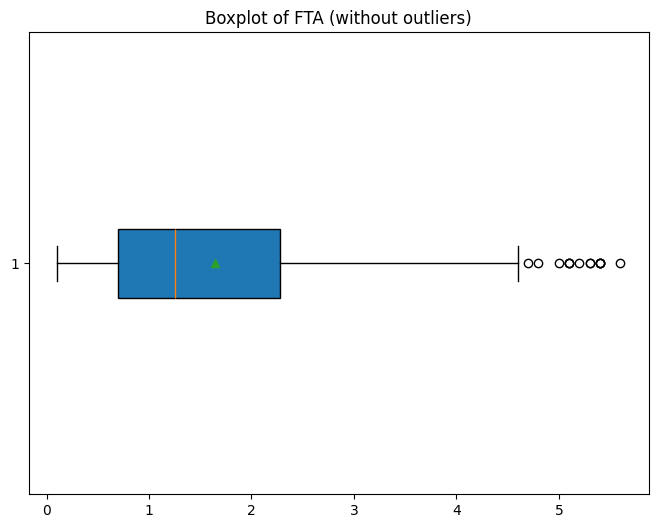

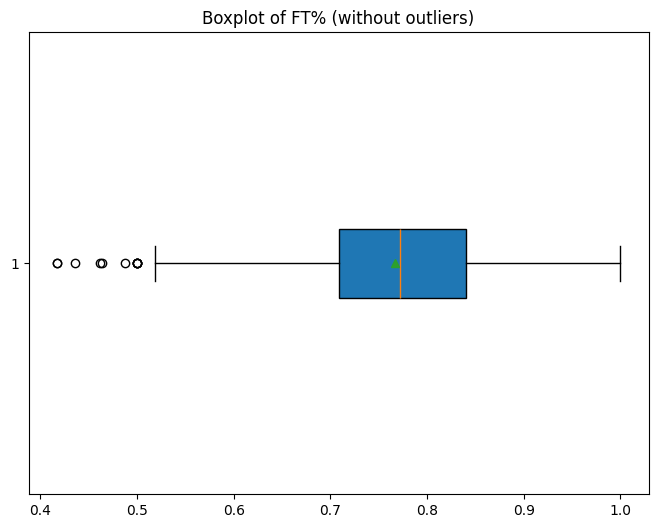

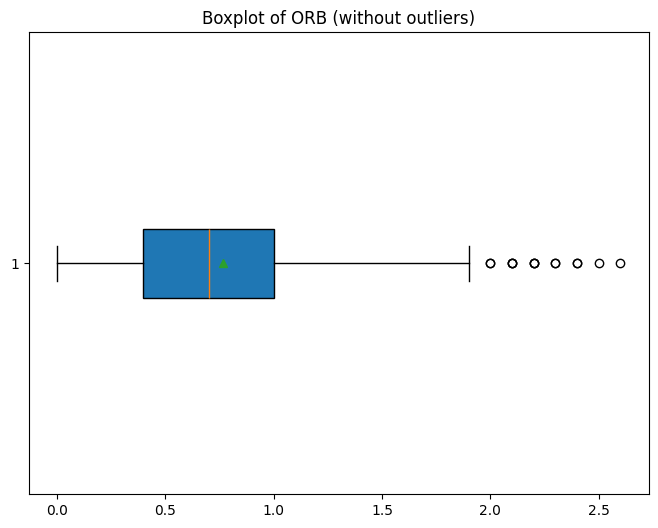

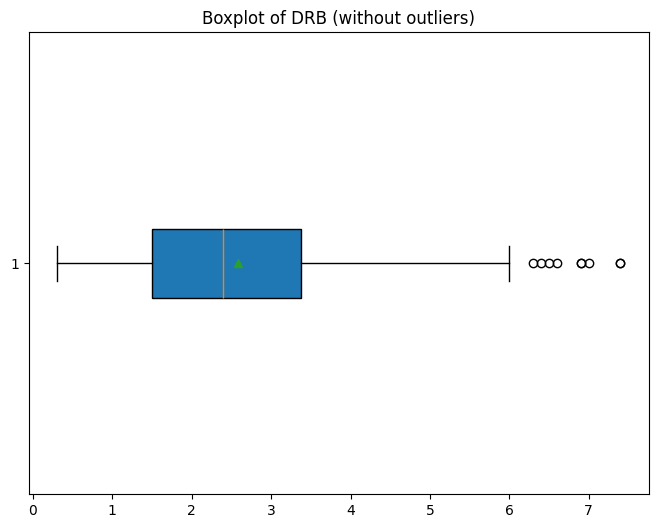

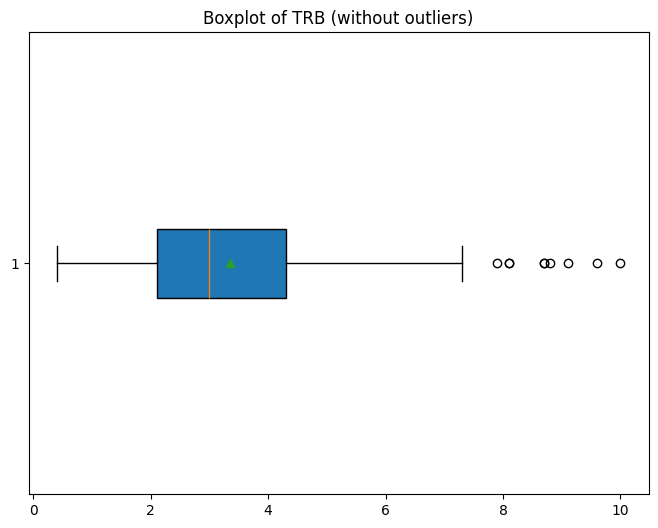

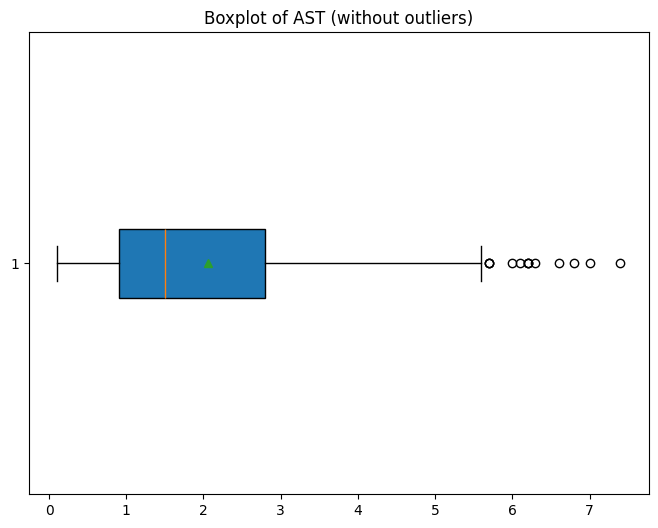

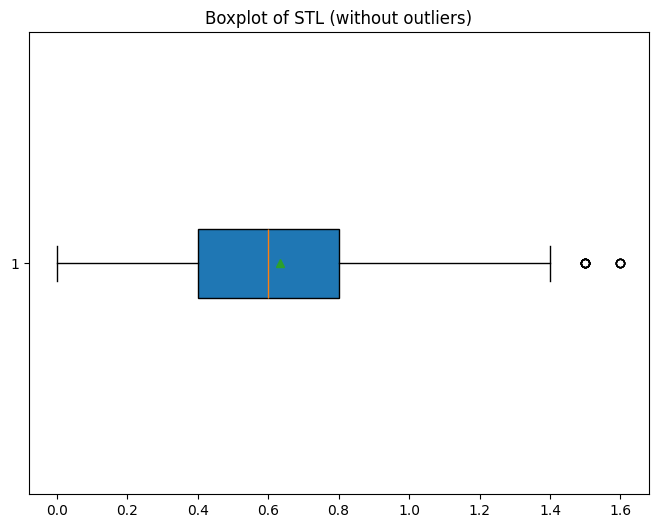

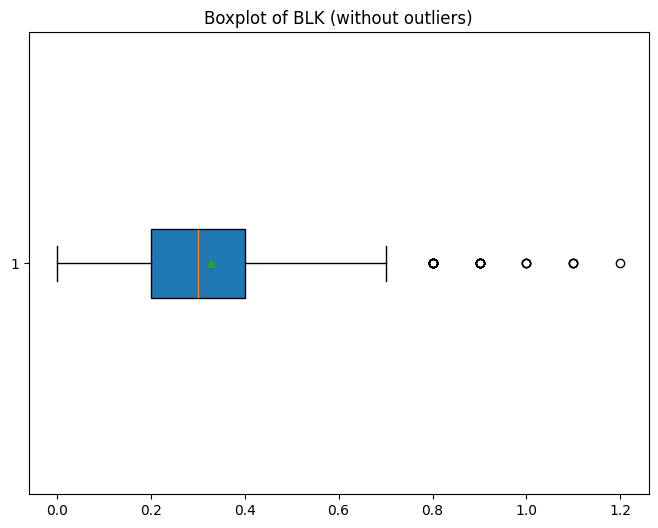

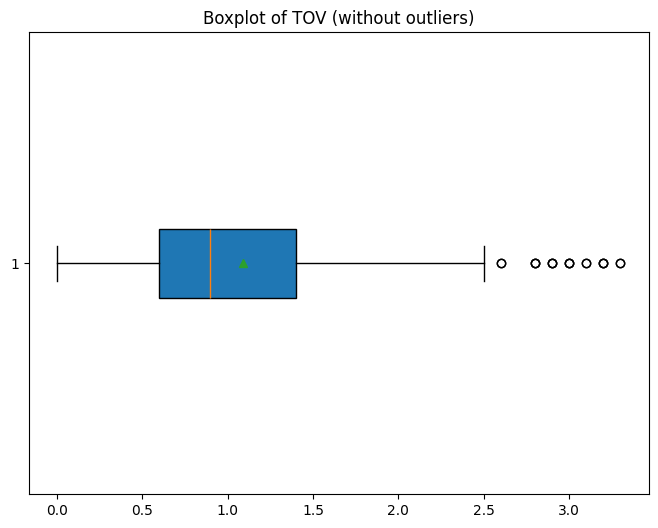

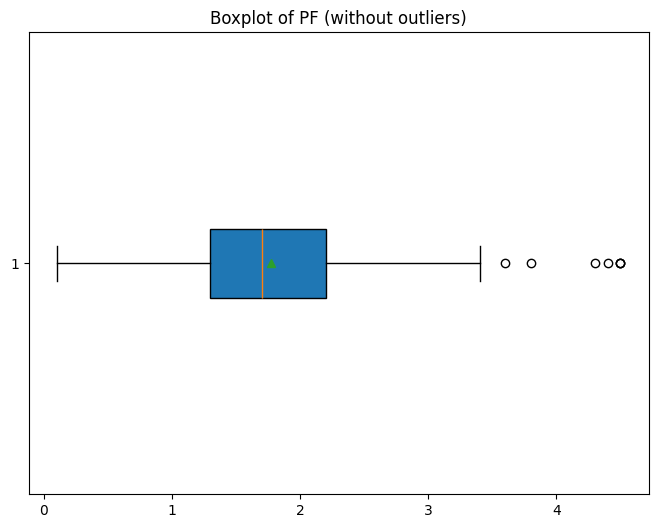

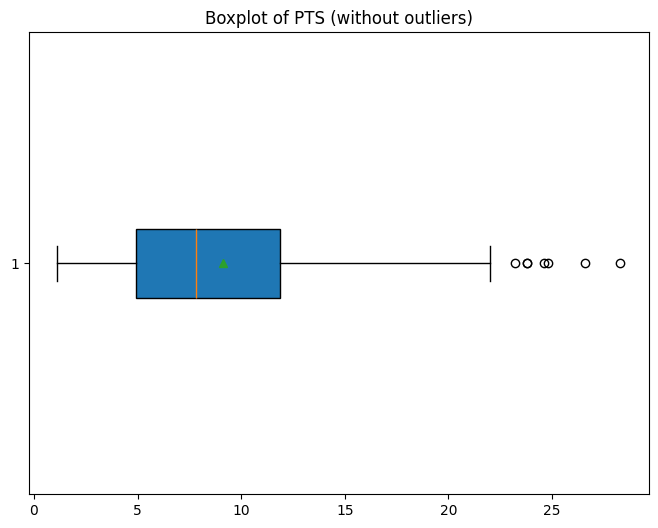

In [ ]:
def remove_outliers_iqr(df):
    cleaned_df = df.copy()
    for column in df.select_dtypes(include=['float64', 'int64']).columns:
        Q1 = df[column].quantile(0.25)
        Q3 = df[column].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        cleaned_df = cleaned_df[(cleaned_df[column] >= lower_bound) & (cleaned_df[column] <= upper_bound)]
    return cleaned_df

df_cleaned = remove_outliers_iqr(df)

for column in df_cleaned.select_dtypes(include=['float64', 'int64']).columns:
    plt.figure(figsize=(8, 6))
    plt.boxplot(df_cleaned[column], vert=False, patch_artist=True, showmeans=True)
    plt.title(f'Boxplot of {column} (without outliers)')
    plt.show()

The next code then **eliminates outliers by the IQR method and subsequently plots the cleaned data**. It first makes a copy of the dataset and computes Q1, Q3, and IQR for every numeric column. **Any values that are more than 1.5 times the IQR away** from Q1 and Q3 are removed, leaving a cleaned dataset free of outliers. It then creates **boxplots for the cleaned columns to display the new distributions**.

In [ ]:
df.to_csv('cleaned_2022-2023 NBA Player Stats - Regular.csv', index=False)

The dataset is saved again upon this point.

In [ ]:
df = pd.DataFrame(index=range(df_cleaned.shape[0]), columns=range(df_cleaned.shape[1]))

print("Shape of the cleaned dataset::", df.shape)

Shape of the cleaned dataset:: (334, 27)


This code creates a new DataFrame with the same number of rows and columns but not copying its actual data. It creates **an empty DataFrame with the same shape instead**. The print statement then verifies that **the cleaned dataset has 334 rows and 27 columns**.

In [ ]:
print("Columns of the cleaned dataset::\n", df_cleaned.columns)

num_columns = len(df_cleaned.columns)

print("\nNumber of columns in the dataset after cleaning:", num_columns)

Columns of the cleaned dataset::
 Index(['Player', 'Age', 'G', 'GS', 'MP', 'FG', 'FGA', 'FG%', '3P', '3PA',
       '3P%', '2P', '2PA', '2P%', 'eFG%', 'FT', 'FTA', 'FT%', 'ORB', 'DRB',
       'TRB', 'AST', 'STL', 'BLK', 'TOV', 'PF', 'PTS'],
      dtype='object')

Number of columns in the dataset after cleaning: 27


The code prints the column headers of `df_cleaned` first, showing that **all 27 columns are still intact** after cleaning. The code then counts and prints the number of columns, confirming that no columns were dropped but rows with outliers were filtered instead. This makes sure that the dataset maintains its original form without extreme values.

In [ ]:
df.to_csv('cleaned_2022-2023 NBA Player Stats - Regular.csv', index=False)

I saved the dataset once again after confirming the state of the dataset.

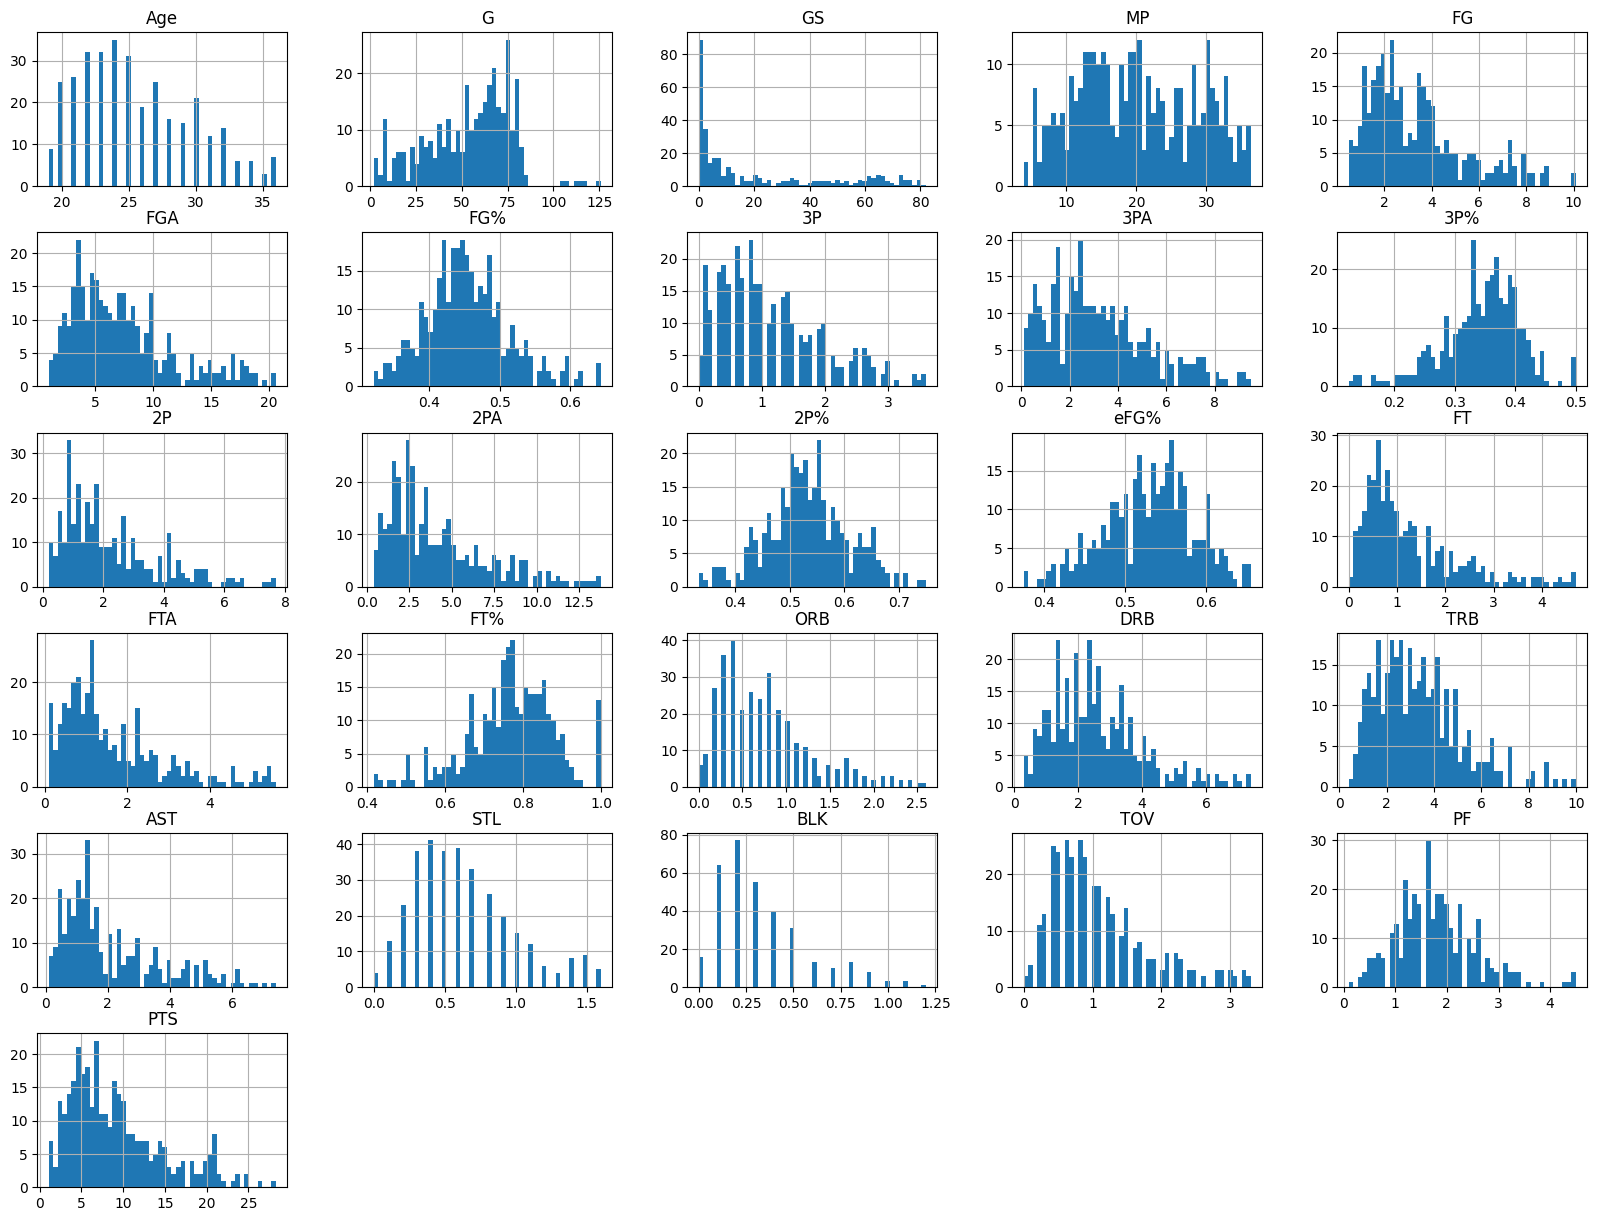

In [ ]:
numerical_columns = df_cleaned.select_dtypes(include=['float64', 'int64']).columns

df_cleaned[numerical_columns].hist(bins=50, figsize=(20, 15))
plt.show()

The code shows out all numeric columns in the cleaned dataset and plots histograms for each one, showing the distribution of the values within different bins. The plots shown are the distribution of numeric variables within the cleaned dataset.

- The statistics do seem to be right-skewed in various metrics, including points (PTS), assists (AST), and turnovers (TOV), implying that the majority of players possess smaller values with some outliers producing substantially higher values.

- Other statistics, including field goal attempts (FGA) and free throw attempts (FTA), also share this skewness.Some of the distributions, such as defensive rebounds (DRB) and minutes played (MP), appear more normally distributed, there are more values distributed around a peak.

- The 50 bin size provides high granularity, and it is easy to visualize differences within each feature. The cleaned data set would have fewer outliers removed and therefore fewer extreme values, leading to more typical distributions of player performance.

# **Attribute Selection**

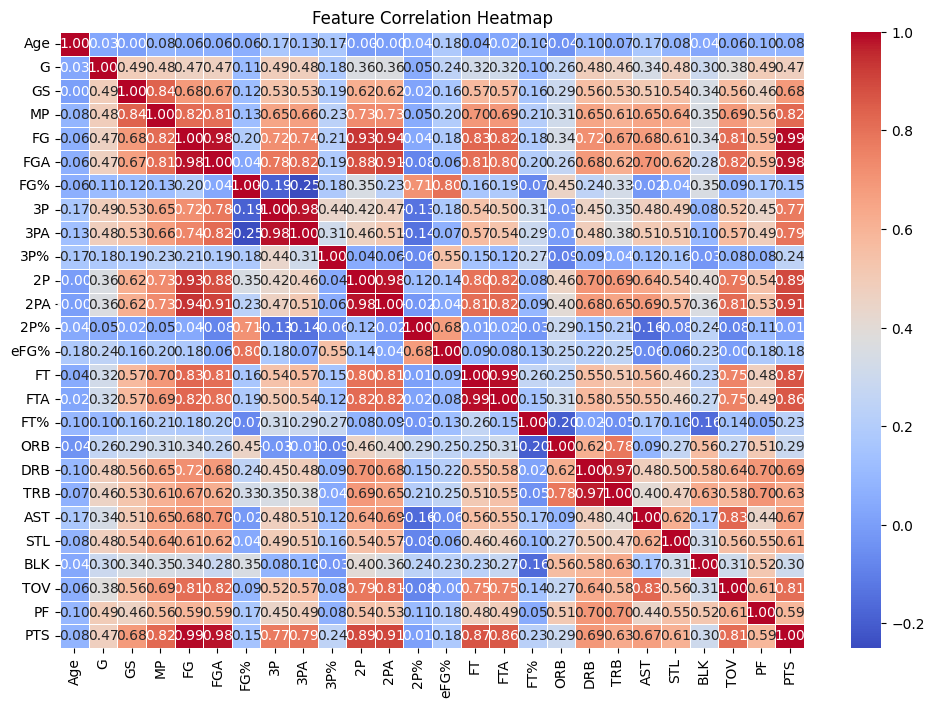

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

correlation_matrix = df_cleaned[numerical_columns].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Feature Correlation Heatmap")
plt.show()

I have utilized a heatmap that shows plots the correlation between numerical features in the dataset, with a color scale where red is used for strong positive correlations and blue for strong negative correlations. Diagonal values are all 1.00 since each feature is perfectly correlated with itself.

I've observed that:

- **Points (PTS) have high positive correlations with field goals (FG), field goal attempts (FGA)**, and **minutes played (MP),** as higher-scoring players will both attempt more shots and play for more minutes.
- **Field goals per game (FG) and field goal attempts (FGA) are almost perfectly correlated (~0.98–0.99)** because, intuitively, having more attempts should lead to more makes.
-**Assists (AST) are moderately related to points (PTS) and minutes played (MP)**, indicating the more playmaking is expected of a player, the more they will assist on scoring.
- **Rebounding statistics (ORB, DRB, TRB) are highly related to one another**, so that players who perform well in one rebounding category tend to perform well across all rebounding categories.
- **eFG% and FG% are highly related**, pointing out that both rates are measures of shooting efficiency but with eFG% being a measure of three-point value.
- **Free throws attempted (FTA) is highly related to free throws made (FT) and points (PTS)**, consistent with the view that players who reach the line tend to contribute heavily to scoring.
- **Turnovers (TOV) have medium correlations with assists (AST)** such that they also have higher chances of being at risk with high-assists players.

In [ ]:
numerical_columns = df_cleaned.select_dtypes(include=['float64', 'int64']).columns

correlation_results = {}
target_attribute = 'FGA'
for attribute in numerical_columns:
    correlation_coefficient = df_cleaned[attribute].corr(df_cleaned[target_attribute])
    correlation_results[attribute] = correlation_coefficient

print("Correlation coefficients of each numerical attribute with 'target' attribute:")
for attribute, correlation_coefficient in correlation_results.items():
    print(f"{attribute}: {correlation_coefficient}")

Correlation coefficients of each numerical attribute with 'target' attribute:
Age: 0.06411233701966355
G: 0.4709072164079797
GS: 0.6668997899026181
MP: 0.8053665643425372
FG: 0.9820011822313364
FGA: 1.0
FG%: 0.03668329522183154
3P: 0.7811247196027808
3PA: 0.8181766718602751
3P%: 0.18636474202710873
2P: 0.8789574478081833
2PA: 0.9114231921192107
2P%: -0.08047889506020736
eFG%: 0.057698403523500696
FT: 0.8085753249815283
FTA: 0.8034912927628584
FT%: 0.20105649258432073
ORB: 0.26346100480766765
DRB: 0.6848340938468298
TRB: 0.6170129534967008
AST: 0.7003298184219823
STL: 0.62495215000699
BLK: 0.2844348573151982
TOV: 0.8153656932133828
PF: 0.5887689844606658
PTS: 0.9834709892291885


Correlation coefficients state how strong each quantitative trait correlation is with Field Goal Attempts (FGA). Following are some observations from the results:

`Strong Positive Correlations:`

- **Field Goals Made (FG) (0.982) and Points (PTS) (0.983)**: the more shots taken, there would be more points.
- **Minutes Played (MP) (0.805)**: More minutes played, more shots taken.
- **Two-Point Attempts (2PA) (0.911) and Three-Point Attempts (3PA) (0.818)**: Shot-takers also try more three-pointers and two-pointers.
- **Free Throws Made (FT) (0.809) and Attempted (FTA) (0.803)**: It suggests that players with high field goal attemptsare also being fouled and getting to the free-throw line.

`Moderate Positive Correlations:`

- **Games Played (G) (0.471) and Games Started (GS) (0.667)**: More games played and starts per game are likely to equate to more time shooting.
- **Defensive Rebounds (DRB) (0.685) and Total Rebounds (TRB) (0.617)**: Rebounding may be correlated with more shots attempted, maybe as a second-order effect of second-chance opportunities.
-**Assists (AST) (0.700) and Turnovers (TOV) (0.815)**: players that are often playing takes more shot attempts and turnovers.
- **Steals (STL) (0.625) and Blocks (BLK) (0.284)**: Defense provides the opportunity for transition scoring.

`Weak or Negligible Correlations:`

- **Age (0.064)**: Shot attempts are minimally affected by age.
- **Field Goal Percentage (FG%) (0.037) and Effective FG% (eFG%) (0.058)**: Shot efficiency is weakly correlated with attempts.
- **Two-Point Percentage (2P%) (-0.080)**: A low negative correlation means that high-volume shooters shoot less.

Overall, this analysis derives that shot attempts (FGA) are significantly influenced by scoring ability, rebounding, minutes, and playmaking involvement.


Enter the predictor attribute: PTS
Enter the target attribute: FGA

Correlation coefficient (r) between PTS and FGA: 0.9834709892291885



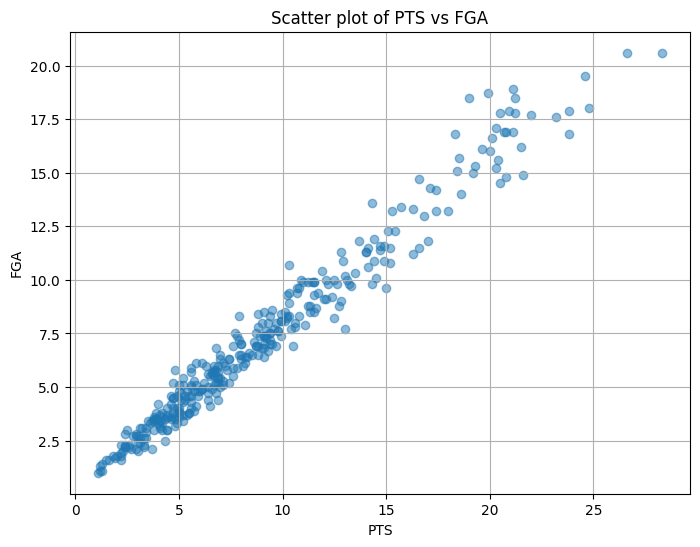

In [ ]:
selected_attributes = {}
def get_valid_attributes():
    selected_attributes["attr1"] = input("\nEnter the predictor attribute: ").strip()
    selected_attributes["attr2"] = input("Enter the target attribute: ").strip()

def calculate_and_plot_correlation(df_cleaned):
    if "attr1" not in selected_attributes or "attr2" not in selected_attributes:
        print("Attributes not set. Please run get_valid_attributes() first.")
        return

    attr1 = selected_attributes["attr1"]
    attr2 = selected_attributes["attr2"]

    correlation_coefficient = df_cleaned[attr1].corr(df_cleaned[attr2])
    print(f"\nCorrelation coefficient (r) between {attr1} and {attr2}: {correlation_coefficient}\n")

    plt.figure(figsize=(8, 6))
    plt.scatter(df_cleaned[attr1], df_cleaned[attr2], alpha=0.5)
    plt.title(f"Scatter plot of {attr1} vs {attr2}")
    plt.xlabel(attr1)
    plt.ylabel(attr2)
    plt.grid(True)
    plt.show()

def main():
    get_valid_attributes()
    calculate_and_plot_correlation(df_cleaned)

if __name__ == "__main__":
    main()

The code then asks for a predictor and a target attribute, computes their correlation coefficient, and plots a scatter plot to see the relationship. In my case, I used **PTS (Points) as the predictor** and **FGA (Field Goal Attempts) as the target** and got a `high positive correlation of 0.983`, which shows that** players scoring more field goal attempts also score more points significantly**. The scatter plot also confirms this by indicating a **distinct upward trend**.

# **Simple Linear Regression**

Linear model intercept: 0.29298287079187624
Linear model coefficient: 0.7776438368834887
R-squared score (training): 0.967
R-squared score (test): 0.969


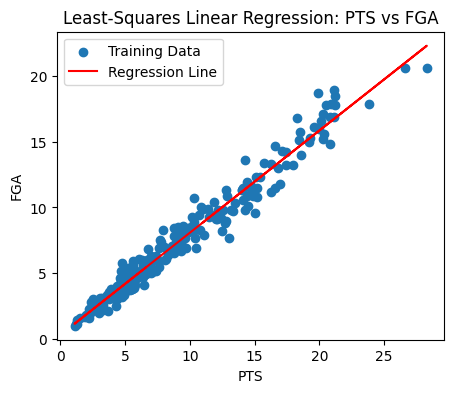

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np

if "attr1" not in selected_attributes or "attr2" not in selected_attributes:
    raise ValueError("Attributes not set. Please run the attribute selection cell first.")

attr1 = selected_attributes["attr1"]
attr2 = selected_attributes["attr2"]


X = df_cleaned[[attr1]]
y = df_cleaned[attr2]

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)

linreg = LinearRegression().fit(X_train, y_train)

print(f'Linear model intercept: {linreg.intercept_}')
print(f'Linear model coefficient: {linreg.coef_[0]}')
print(f'R-squared score (training): {linreg.score(X_train, y_train):.3f}')
print(f'R-squared score (test): {linreg.score(X_test, y_test):.3f}')

plt.figure(figsize=(5, 4))
plt.scatter(X_train, y_train, marker='o', label="Training Data")
plt.plot(X_train, linreg.predict(X_train), 'r-', label="Regression Line")
plt.title(f'Least-Squares Linear Regression: {attr1} vs {attr2}')
plt.xlabel(attr1)
plt.ylabel(attr2)
plt.legend()
plt.show()

The simple linear regression model is helpful in generating key results about the relationship between selected predictor and target variables. The intercept of the linear model is **0.293**, meaning that if the predictor variable is zero, then the target variable would be at the expected value. A linear model coefficient of 0.778 reflects the change of about **0.778 units for the increase of one unit of the predictor variable in the target variable**.

The **R-squared (R²) measures how well the model explains the variation in the target variable**. The R-squared score for the **training set is 0.967 and for the test set is 0.969**. Such high values demonstrate the presence of a strong linear relationship between the predictor and target variables, proving that the model can predict the target variable based upon the predictor. The scatter plot with the regression line visually confirms the relationship. This scatterplot shows how close the data points are following the fitted line, giving evidence to reinforce this model.


In [ ]:
new_value = float(input(f"Enter a new value for {attr1}: "))
new_value_reshaped = np.array([[new_value]])

predicted_target = linreg.predict(new_value_reshaped)
print(f"Model prediction for {attr2}: {predicted_target[0]:.3f}\n")

Enter a new value for PTS: 20
Model prediction for FGA: 15.846



/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


This snippet of code enables prediction of the target variable given a new input value for the predictor variable. The user is able to input a new value for PTS, and then converted to a float. Afterwards, it is reshaped into a format that will suit for prediction. For prediction, the trained simple linear regression model computes the corresponding value for FGA from the relationship determined.

In this case, **when the PTS are 20, the model predicts that the FGA is 15.846, or if a player scores 20 points, they are supposed to attempt approximately 15 field goals**. This is making the prediction based on the learned linear relation from the dataset, further establishing how the model could be used for estimating future outcomes based on past trends.

# **Multiple Linear Regression**

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

predictors = list(df_cleaned.columns)
target = 'FGA'

corr_matrix = df_cleaned.select_dtypes(include=['float64', 'int64']).corr()
print(corr_matrix)

selected_predictors = input("Enter the top predictor attributes to use (comma-separated): ").split(",")

X = df_cleaned[selected_predictors]
y = df_cleaned[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

linreg = LinearRegression()
linreg.fit(X_train, y_train)

print(f"Intercept: {linreg.intercept_}\n")
print("Coefficients:")
for i, col in enumerate(selected_predictors):
    print(f"{col}: {linreg.coef_[i]}")

print(f"\nTraining R-squared score: {linreg.score(X_train, y_train)}")
print(f"Testing R-squared score: {linreg.score(X_test, y_test)}")


           Age         G        GS        MP        FG       FGA       FG%  \
Age   1.000000  0.031042  0.001141  0.082196  0.064610  0.064112  0.059169   
G     0.031042  1.000000  0.487619  0.483732  0.465915  0.470907  0.113953   
GS    0.001141  0.487619  1.000000  0.835580  0.682635  0.666900  0.124650   
MP    0.082196  0.483732  0.835580  1.000000  0.815776  0.805367  0.125169   
FG    0.064610  0.465915  0.682635  0.815776  1.000000  0.982001  0.196913   
FGA   0.064112  0.470907  0.666900  0.805367  0.982001  1.000000  0.036683   
FG%   0.059169  0.113953  0.124650  0.125169  0.196913  0.036683  1.000000   
3P    0.166675  0.486299  0.532275  0.650525  0.719878  0.781125 -0.186630   
3PA   0.134431  0.481112  0.534388  0.663142  0.742333  0.818177 -0.250048   
3P%   0.168482  0.179664  0.189961  0.232638  0.208530  0.186365  0.182514   
2P   -0.001742  0.357430  0.616150  0.727837  0.933541  0.878957  0.349733   
2PA  -0.000290  0.361144  0.615438  0.730489  0.938650  0.911423

The multiple linear regression model predicts FGA based on three key predictor variables: **PTS, 2PA, and FG.** The `R² value on the training data was 0.9708 and on the testing data was 0.9684`. This implies that **nearly 97% of the variance in FGA is explained by the selected predictors**, and a minimal gap between training and testing scores indicates a good generalization of the model to new data.

Each coefficient represents the change in FGA for a one-unit increase in the respective predictor, assuming that all other variables are held constant.

- **Points Scored (PTS) has the largest effect of 0.4867**. This means that for every additional point scored, FGA increases about 0.49 attempts per extra point.

- **The Field Goals Made (FG) coefficient of 0.7134** implies that for each shot made, there are about 0.71 shots taken, which is intuitive as making the shot usually requires the act of taking the shot.

- **Lastly, Two-Point Attempts (2PA) has a smaller coefficient of 0.0688**, which indicates a weaker but still positive relationship with FGA.

Overall, the results support the fact that the more effective players take more shots, and the robust explanatory power of the model indicates that those three variables are good predictors of shot attempts.



In [ ]:
df.to_csv('cleaned_2022-2023 NBA Player Stats - Regular.csv', index=False)

Finally, I saved the dataset file for the last time.